In [ ]:
# ============================================================
# PHASE 3 — PATHS AND DATA
# ============================================================


import os
import json
import math
import random
import re
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Reasoning dataset generated in previous step
# ------------------------------------------------------------

DATA_DIR = Path(
    "/kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names"
)

TRAIN_FILE = DATA_DIR / "train.jsonl"
VAL_FILE = DATA_DIR / "validation.jsonl"
TEST_FILE = DATA_DIR / "test.jsonl"


# ------------------------------------------------------------
# Phase 3 output directory
# ------------------------------------------------------------

PHASE3_DIR = Path(
    "/kaggle/working/nepali_phase3"
)

PHASE3_DIR.mkdir(
    parents=True,
    exist_ok=True
)

ATTENTION_DIR = PHASE3_DIR / "attention"

ATTENTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Pretrained checkpoint
#
#
checkpoint_path ="/kaggle/input/models/saitanoojtadepalli/nepali-models/pytorch/default/1/checkpoints_nepali/nepali_stable_latest_ckpt.pt"
# ------------------------------------------------------------

PRETRAINED_CHECKPOINT = checkpoint_path


assert TRAIN_FILE.exists(), TRAIN_FILE
assert VAL_FILE.exists(), VAL_FILE
assert TEST_FILE.exists(), TEST_FILE
assert os.path.exists(PRETRAINED_CHECKPOINT)


def load_jsonl(path):
    examples = []

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:
            examples.append(
                json.loads(line)
            )

    return examples


train_examples = load_jsonl(TRAIN_FILE)
val_examples = load_jsonl(VAL_FILE)
test_examples = load_jsonl(TEST_FILE)


print("Train      :", len(train_examples))
print("Validation :", len(val_examples))
print("Test       :", len(test_examples))

assert len(train_examples) == 9600
assert len(val_examples) == 1200
assert len(test_examples) == 1200

print("\n✓ Reasoning dataset loaded.")

Train      : 9600
Validation : 1200
Test       : 1200

✓ Reasoning dataset loaded.


In [ ]:


print("TRAIN FILE:", TRAIN_FILE)
print("VAL FILE  :", VAL_FILE)
print("TEST FILE :", TEST_FILE)




TRAIN FILE: /kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/train.jsonl
VAL FILE  : /kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/validation.jsonl
TEST FILE : /kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/test.jsonl


In [ ]:
# ============================================================
# FINETUNING CONFIGURATION
# ============================================================

# WHAT THIS CELL DOES

FT_CONFIG = {
    "epochs": 3,
    "batch_size": 16,
    "learning_rate": 5e-5,
    "weight_decay": 0.01,
    "max_length": 256,
    "gradient_clip": 1.0,
    "warmup_ratio": 0.05,
    "seed": 42,
}

print(FT_CONFIG)

with open(
    PHASE3_DIR / "finetune_config.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        FT_CONFIG,
        f,
        indent=2
    )

{'epochs': 3, 'batch_size': 16, 'learning_rate': 5e-05, 'weight_decay': 0.01, 'max_length': 256, 'gradient_clip': 1.0, 'warmup_ratio': 0.05, 'seed': 42}


In [ ]:
# ============================================================
# LOAD TELUGU TOKENIZER FROM KAGGLE INPUT
# ============================================================

import os
import sentencepiece as spm


# Search Kaggle inputs for nepali_sp (1).model
tokenizer_path = "/kaggle/input/models/saitanoojtadepalli/nepali-tokenizer/pytorch/default/1/nepali_sp (1).model"

for root, dirs, files in os.walk("/kaggle/input"):
    if "nepali_sp (1).model" in files:
        tokenizer_path = os.path.join(
            root,
            "nepali_sp (1).model"
        )
        break


# Make sure tokenizer was found
assert tokenizer_path is not None, (
    "nepali_sp (1).model was not found in /kaggle/input"
)


print("Tokenizer path:")
print(tokenizer_path)


# Load SAME tokenizer trained in Phase 1
sp = spm.SentencePieceProcessor(
    model_file=tokenizer_path
)


print("\n✓ Nepali tokenizer loaded successfully")

print("Vocabulary size :", sp.get_piece_size())
print("PAD ID          :", sp.pad_id())
print("BOS ID          :", sp.bos_id())
print("EOS ID          :", sp.eos_id())
print("UNK ID          :", sp.unk_id())

Tokenizer path:
/kaggle/input/models/saitanoojtadepalli/nepali-tokenizer/pytorch/default/1/nepali_sp (1).model

✓ Nepali tokenizer loaded successfully
Vocabulary size : 10000
PAD ID          : 0
BOS ID          : 2
EOS ID          : 3
UNK ID          : 1


In [ ]:
# ============================================================
# PYTORCH REASONING DATASET
# ============================================================

# WHAT THIS CELL DOES
# Defines the PyTorch Dataset/collate pipeline for the reasoning-finetuning data.
#
# Each example is turned into: <question prefix><prompt><answer prefix><answer>,
# tokenized as one sequence. Labels mirror input_ids but with every *prompt*
# token replaced by -100 (PyTorch's cross-entropy "ignore this position" value),
# so the loss is only ever computed on the answer tokens .the model is trained
# to generate answers, not to relearn how to reproduce the question.
#

QUESTION_PREFIX = "प्रश्न:\n"
ANSWER_PREFIX = "\nजवाफ:\n"

MAX_LENGTH = FT_CONFIG["max_length"]


# ------------------------------------------------------------
# Padding token
# ------------------------------------------------------------

PAD_ID = sp.pad_id()

if PAD_ID < 0:

    if sp.eos_id() >= 0:
        PAD_ID = sp.eos_id()
    else:
        PAD_ID = 0


EOS_ID = sp.eos_id()

print("PAD ID:", PAD_ID)
print("EOS ID:", EOS_ID)


class ReasoningDataset(Dataset):

    def __init__(
        self,
        examples,
        tokenizer,
        max_length
    ):

        self.examples = examples
        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):

        return len(self.examples)


    def __getitem__(self, index):

        example = self.examples[index]

        prompt_text = (
            QUESTION_PREFIX
            + example["prompt"]
            + ANSWER_PREFIX
        )

        answer_text = example["answer"]


        # Prompt tokens
        prompt_ids = self.tokenizer.encode(
            prompt_text,
            out_type=int
        )


        # Answer tokens
        answer_ids = self.tokenizer.encode(
            answer_text,
            out_type=int
        )


        # Complete sequence
        input_ids = (
            prompt_ids
            + answer_ids
        )


        # Add EOS if tokenizer contains one
        if EOS_ID >= 0:
            input_ids.append(EOS_ID)


        # ----------------------------------------------------
        # Labels
        #
        # -100 means:
        # do NOT calculate loss for these tokens.
        #
        # Therefore prompt is context,
        # while answer is supervised.
        # ----------------------------------------------------

        labels = (
            [-100] * len(prompt_ids)
            + answer_ids
        )

        if EOS_ID >= 0:
            labels.append(EOS_ID)


        # Reasoning examples should be short.
        # We assert rather than silently truncating.
        assert len(input_ids) <= self.max_length, (
            f"Example exceeds max length: "
            f"{len(input_ids)}"
        )


        return {
            "input_ids": torch.tensor(
                input_ids,
                dtype=torch.long
            ),

            "labels": torch.tensor(
                labels,
                dtype=torch.long
            ),

            "template": example["template"],
        }


# ============================================================
# COLLATE FUNCTION
# ============================================================

def collate_batch(batch):

    batch_size = len(batch)

    max_len = max(
        len(item["input_ids"])
        for item in batch
    )

    input_ids = torch.full(
        (batch_size, max_len),
        PAD_ID,
        dtype=torch.long
    )

    labels = torch.full(
        (batch_size, max_len),
        -100,
        dtype=torch.long
    )


    for i, item in enumerate(batch):

        length = len(
            item["input_ids"]
        )

        input_ids[i, :length] = (
            item["input_ids"]
        )

        labels[i, :length] = (
            item["labels"]
        )


    return input_ids, labels


train_dataset = ReasoningDataset(
    train_examples,
    sp,
    MAX_LENGTH
)

val_dataset = ReasoningDataset(
    val_examples,
    sp,
    MAX_LENGTH
)


train_loader = DataLoader(
    train_dataset,
    batch_size=FT_CONFIG["batch_size"],
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=FT_CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=True
)


print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))


# Sanity check

input_ids, labels = next(
    iter(train_loader)
)

print("\nInput shape :", input_ids.shape)
print("Label shape :", labels.shape)

PAD ID: 0
EOS ID: 3
Train batches: 600
Validation batches: 75

Input shape : torch.Size([16, 86])
Label shape : torch.Size([16, 86])


In [ ]:
# ============================================================
# GREEDY REASONING GENERATION
# ============================================================

# WHAT THIS CELL DOES
# generate_reasoning_answer(): greedy (argmax) autoregressive decoding. Feeds the
# question, then repeatedly asks the model for the most likely next token and
# appends it, stopping at EOS or after max_new_tokens. No sampling / temperature —
# deterministic, which keeps evaluation reproducible and comparable across runs.
# Truncates context to the model's max_seq_len (sliding window) if it ever got
# that long, though reasoning prompts are short so this shouldn't normally trigger.
#
# normalize_answer(): strips whitespace/punctuation noise and keeps only the
# first line, so a correct answer buried in extra generated text (or trailing
# punctuation) still counts as an exact match against the gold answer.

@torch.inference_mode()
def generate_reasoning_answer(
    model,
    prompt,
    max_new_tokens=12
):

    model.eval()

    prefix = (
        QUESTION_PREFIX
        + prompt
        + ANSWER_PREFIX
    )

    ids = sp.encode(
        prefix,
        out_type=int
    )

    input_ids = torch.tensor(
        ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)


    generated_ids = []


    for _ in range(max_new_tokens):

        context = input_ids[
            :,
            -config["max_seq_len"]:
        ]

        logits = model(context)

        next_token = torch.argmax(
            logits[:, -1, :],
            dim=-1,
            keepdim=True
        )

        token_id = (
            next_token.item()
        )


        # Stop at EOS
        if EOS_ID >= 0 and token_id == EOS_ID:
            break


        generated_ids.append(
            token_id
        )


        input_ids = torch.cat(
            [
                input_ids,
                next_token
            ],
            dim=1
        )


    text = sp.decode(
        generated_ids
    )

    return text


# ============================================================
# NORMALIZE ANSWER
# ============================================================

def normalize_answer(text):

    text = text.strip()

    # Take first output line
    if "\n" in text:
        text = text.split("\n")[0]

    text = text.strip()

    # Remove common trailing punctuation
    text = text.strip(
        " \t\r\n.,!?;:।-–—"
    )

    # Normalize repeated spaces
    text = " ".join(
        text.split()
    )

    return text

In [ ]:
# ============================================================
# EXACT MATCH EVALUATION
# ============================================================

# WHAT THIS CELL DOES
# evaluate_reasoning(): runs generate_reasoning_answer() over a whole split,
# normalizes both prediction and gold answer, and scores exact string match.
# Tracks accuracy per-template (T1..T6) as well as overall, since different
# reasoning templates are expected to have very different difficulty.

def evaluate_reasoning(
    model,
    examples,
    description
):

    results = []

    correct = 0

    template_correct = defaultdict(int)
    template_total = defaultdict(int)


    for example in tqdm(
        examples,
        desc=description
    ):

        predicted = (
            generate_reasoning_answer(
                model,
                example["prompt"]
            )
        )

        predicted_clean = normalize_answer(
            predicted
        )

        gold_clean = normalize_answer(
            example["answer"]
        )

        is_correct = (
            predicted_clean
            == gold_clean
        )


        if is_correct:
            correct += 1

        template = example["template"]

        template_total[template] += 1

        if is_correct:
            template_correct[template] += 1


        results.append({
            "id": example["id"],
            "template": template,
            "prompt": example["prompt"],
            "gold": gold_clean,
            "prediction": predicted_clean,
            "correct": is_correct,
        })


    overall_accuracy = (
        correct / len(examples)
    )


    template_accuracy = {}

    for template in sorted(
        template_total
    ):

        template_accuracy[template] = (
            template_correct[template]
            / template_total[template]
        )


    metrics = {
        "overall_exact_match":
            overall_accuracy,

        "template_accuracy":
            template_accuracy,
    }


    return metrics, results

In [8]:
# Pick GPU if available, else fall back to CPU. Every tensor/model below is
# moved onto this device.

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [ ]:
# WHAT THIS CELL DOES

config = {
    "vocab_size": 10000,
    "max_seq_len": 512,
    "qkv_bias": False,
    "d_model": 384,
    "n_layers": 12,
    "n_heads": 8,
    "d_ff": 1536,
    "dropout": 0.1,
}

In [ ]:
# ============================================================
# CELL 14 — IMPORTS AND DEVICE
# ============================================================


import os
import json
import math
import random

from pathlib import Path
from collections import Counter, defaultdict

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm

from tqdm.auto import tqdm


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [11]:
# WHAT THIS CELL DOES
# The decoder-only Transformer architecture, copied verbatim from the Phase 2
# notebook so that the class definition — and therefore the state_dict key
# names — match the saved checkpoint exactly. Reimplementing this from memory
# instead of copying it risks subtly different layer names/order, which would
# make load_state_dict(..., strict=True) fail below.
#
# Components, bottom-up:
#  - MultiHeadCausalSelfAttention: scaled dot-product attention with a causal
#    (upper-triangular) mask so position t can only attend to positions <= t.
#    Supports returning raw attention weights for the Phase 3 attention analysis.
#  - FeedForward: standard two-layer GELU MLP applied per-position.
#  - TransformerBlock: pre-norm residual block (LayerNorm -> attn -> residual,
#    LayerNorm -> FFN -> residual).
#  - DecoderOnlyTransformerLM: token + learned positional embeddings, a stack of
#    TransformerBlocks, a final LayerNorm, and a tied output projection (the
#    LM head reuses the input embedding matrix, which is a standard GPT-style
#    trick that saves vocab_size * d_model parameters).
#  - `Transformer = DecoderOnlyTransformerLM` alias so the rest of the notebook,
#    written against the name "Transformer", doesn't need to change.

# ============================================================
# CELL 15 — EXACT PHASE 2 TRANSFORMER MODEL
# (pulled verbatim from nepali-phase2-final.ipynb so the state_dict
#  keys match the checkpoint exactly)
# ============================================================

# ============================================================
# 3A. MULTI-HEAD CAUSAL SELF-ATTENTION — IMPLEMENTED FROM SCRATCH
# ============================================================

class MultiHeadCausalSelfAttention(nn.Module):
    """Student-implemented scaled dot-product multi-head causal self-attention."""

    def __init__(self, cfg):
        super().__init__()
        d_model = cfg["d_model"]
        n_heads = cfg["n_heads"]
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv = nn.Linear(d_model, 3 * d_model, bias=cfg["qkv_bias"])
        self.out_proj = nn.Linear(d_model, d_model, bias=True)
        self.attn_dropout = nn.Dropout(cfg["dropout"])

        # True means "masked / forbidden". Register as a buffer so it follows the model device.
        causal_mask = torch.triu(
            torch.ones(cfg["max_seq_len"], cfg["max_seq_len"], dtype=torch.bool),
            diagonal=1,
        )
        self.register_buffer("causal_mask", causal_mask, persistent=False)

    def forward(self, x, return_attention=False):
        """
        Args:
            x: (B, T, d_model)
            return_attention: when True, also return attention probabilities.
        Returns:
            context: (B, T, d_model)
            optionally attention weights: (B, n_heads, T, T)
        """
        B, T, C = x.shape
        if T > self.causal_mask.size(0):
            raise ValueError(f"Sequence length {T} exceeds max_seq_len={self.causal_mask.size(0)}")

        qkv = self.qkv(x)                    # (B, T, 3C)
        q, k, v = qkv.chunk(3, dim=-1)      # each (B, T, C)

        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # (B,H,T,Dh)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # Scaling prevents dot-product variance from growing with head dimension.
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (B,H,T,T)
        mask = self.causal_mask[:T, :T]
        scores = scores.masked_fill(mask, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn = self.attn_dropout(attn)

        context = attn @ v                                             # (B,H,T,Dh)
        context = context.transpose(1, 2).contiguous().view(B, T, C)   # (B,T,C)
        context = self.out_proj(context)

        if return_attention:
            return context, attn
        return context


# ============================================================
# 3B. FEED-FORWARD NETWORK AND PRE-NORM TRANSFORMER BLOCK
# ============================================================

class FeedForward(nn.Module):
    """Position-wise two-layer GELU feed-forward network."""

    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg["d_model"], cfg["d_ff"])
        self.fc2 = nn.Linear(cfg["d_ff"], cfg["d_model"])
        self.dropout = nn.Dropout(cfg["dropout"])

    def forward(self, x):
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)
        return self.dropout(x)


class TransformerBlock(nn.Module):
    """Pre-norm decoder block with causal MHA, FFN, residuals, and dropout."""

    def __init__(self, cfg):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg["d_model"], eps=1e-5)
        self.attn = MultiHeadCausalSelfAttention(cfg)
        self.attn_resid_dropout = nn.Dropout(cfg["dropout"])

        self.ln2 = nn.LayerNorm(cfg["d_model"], eps=1e-5)
        self.ffn = FeedForward(cfg)

    def forward(self, x, return_attention=False):
        if return_attention:
            attn_out, attn_weights = self.attn(self.ln1(x), return_attention=True)
            x = x + self.attn_resid_dropout(attn_out)
            x = x + self.ffn(self.ln2(x))
            return x, attn_weights

        x = x + self.attn_resid_dropout(self.attn(self.ln1(x)))
        x = x + self.ffn(self.ln2(x))
        return x


# ============================================================
# 3C. COMPLETE DECODER-ONLY LANGUAGE MODEL
# ============================================================

class DecoderOnlyTransformerLM(nn.Module):
    """GPT-style decoder-only Transformer LM built from primitive PyTorch layers."""

    def __init__(self, cfg):
        super().__init__()
        self.cfg = dict(cfg)

        self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["d_model"])
        self.position_embedding = nn.Embedding(cfg["max_seq_len"], cfg["d_model"])
        self.embedding_dropout = nn.Dropout(cfg["dropout"])

        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_ln = nn.LayerNorm(cfg["d_model"], eps=1e-5)
        self.lm_head = nn.Linear(cfg["d_model"], cfg["vocab_size"], bias=False)

        self.apply(self._init_weights)

        # GPT-style scaled initialization for projections that write into the residual stream.
        residual_std = 0.02 / math.sqrt(2 * cfg["n_layers"])
        for block in self.blocks:
            nn.init.normal_(block.attn.out_proj.weight, mean=0.0, std=residual_std)
            nn.init.normal_(block.ffn.fc2.weight, mean=0.0, std=residual_std)

        # Weight tying saves vocab_size*d_model parameters and is allowed by the assignment.
        if cfg.get("tie_embeddings", True):
            self.lm_head.weight = self.token_embedding.weight

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, token_ids, return_attentions=False):
        """
        Args:
            token_ids: (B, T)
        Returns:
            logits: (B, T, vocab_size)
            optionally list of per-layer attention tensors.
        """
        B, T = token_ids.shape
        if T > self.cfg["max_seq_len"]:
            raise ValueError(f"T={T} exceeds max_seq_len={self.cfg['max_seq_len']}")

        positions = torch.arange(T, device=token_ids.device)
        x = self.token_embedding(token_ids) + self.position_embedding(positions)[None, :, :]
        x = self.embedding_dropout(x)

        attentions = []
        for block in self.blocks:
            if return_attentions:
                x, attn = block(x, return_attention=True)
                attentions.append(attn)
            else:
                x = block(x)

        x = self.final_ln(x)
        logits = self.lm_head(x)

        if return_attentions:
            return logits, attentions
        return logits


def unwrap_model(model):
    """Return the underlying module when DataParallel is used."""
    return model.module if isinstance(model, nn.DataParallel) else model


# ------------------------------------------------------------
# Alias so the rest of this notebook (which calls Transformer(config))
# does not need to change.
# ------------------------------------------------------------
Transformer = DecoderOnlyTransformerLM


In [ ]:
# ============================================================
# CELL 16 — VERIFY MODEL CLASS
# ============================================================


assert "Transformer" in globals()

print("Transformer class exists:")
print(Transformer)


test_model = Transformer(
    config
).to(device)


parameter_count = sum(
    p.numel()
    for p in test_model.parameters()
)


print(
    f"\nParameter count: "
    f"{parameter_count:,}"
)


del test_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Transformer class exists:
<class '__main__.DecoderOnlyTransformerLM'>

Parameter count: 25,317,120


In [13]:
# ============================================================
# CELL 18 — FIND PHASE 2 CHECKPOINT
# ============================================================

# The exact Kaggle input path for a dataset changes across attaches/versions,
# so rather than hardcoding it, walk /kaggle/input for any .pt/.pth file whose
# path contains "nepali" — that's our set of candidate pretrained checkpoints.

checkpoint_candidates = []


for root, dirs, files in os.walk(
    "/kaggle/input"
):

    for filename in files:

        if filename.endswith(
            (".pt", ".pth")
        ):

            full_path = os.path.join(
                root,
                filename
            )

            if "nepali" in full_path.lower():

                checkpoint_candidates.append(
                    full_path
                )


print("Checkpoint files found:\n")

for path in checkpoint_candidates:
    print(path)


assert len(checkpoint_candidates) > 0, (
    "No Nepali checkpoint found!"
)

Checkpoint files found:

/kaggle/input/models/saitanoojtadepalli/nepali-models/pytorch/default/1/checkpoints_nepali/nepali_stable_latest_ckpt.pt
/kaggle/input/models/saitanoojtadepalli/nepali-models/pytorch/default/1/checkpoints_nepali/nepali_stable_best_ckpt.pt


In [ ]:
# ============================================================
# CELL 19 — LOAD PHASE 2 PRETRAINED MODEL
# ============================================================

latest_candidates = [
    path
    for path in checkpoint_candidates
    if "latest" in path.lower()
]


if len(latest_candidates) > 0:

    checkpoint_path = (
        latest_candidates[0]
    )

else:

    checkpoint_path = (
        checkpoint_candidates[0]
    )


print(
    "Using checkpoint:"
)

print(
    checkpoint_path
)


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = Transformer(
    config
).to(device)


# ------------------------------------------------------------
# Load checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)


print(
    "\nCheckpoint keys:"
)

print(
    checkpoint.keys()
)


# ------------------------------------------------------------
# Load pretrained weights
# ------------------------------------------------------------

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ],
    strict=True
)


model.eval()


print(
    "\n✓ Phase 2 Nepali pretrained "
    "model loaded successfully."
)

Using checkpoint:
/kaggle/input/models/saitanoojtadepalli/nepali-models/pytorch/default/1/checkpoints_nepali/nepali_stable_latest_ckpt.pt

Checkpoint keys:
dict_keys(['step', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'scaler_state_dict', 'config', 'training_config', 'history', 'best_val_loss', 'rng_state'])

✓ Phase 2 Nepali pretrained model loaded successfully.


In [ ]:
# ============================================================
# CELL 20 — FIND REASONING DATASET
# ============================================================

jsonl_files = []


for root, dirs, files in os.walk(
    "/kaggle/input"
):

    for filename in files:

        if filename.endswith(
            ".jsonl"
        ):

            full_path = os.path.join(
                root,
                filename
            )

            if (
                "phase3" in full_path.lower()
                or
                "reasoning" in full_path.lower()
            ):

                jsonl_files.append(
                    full_path
                )


print("Reasoning JSONL files found:\n")

for path in jsonl_files:
    print(path)

Reasoning JSONL files found:

/kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/test.jsonl
/kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/validation.jsonl
/kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/train.jsonl


In [ ]:
# ============================================================
# CELL 21 — SET REASONING DATA PATHS
# ============================================================

TRAIN_FILE = None
VAL_FILE = None
TEST_FILE = None


for path in jsonl_files:

    filename = os.path.basename(
        path
    ).lower()


    if filename == "train.jsonl":

        TRAIN_FILE = path


    elif filename in [
        "validation.jsonl",
        "val.jsonl"
    ]:

        VAL_FILE = path


    elif filename == "test.jsonl":

        TEST_FILE = path


print("Train      :", TRAIN_FILE)
print("Validation :", VAL_FILE)
print("Test       :", TEST_FILE)


assert TRAIN_FILE is not None
assert VAL_FILE is not None
assert TEST_FILE is not None

Train      : /kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/train.jsonl
Validation : /kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/validation.jsonl
Test       : /kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/test.jsonl


In [ ]:
# ============================================================
# CELL 22 — LOAD REASONING DATA
# ============================================================

def load_jsonl(path):

    examples = []

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        for line in f:

            examples.append(
                json.loads(line)
            )


    return examples


train_examples = load_jsonl(
    TRAIN_FILE
)

val_examples = load_jsonl(
    VAL_FILE
)

test_examples = load_jsonl(
    TEST_FILE
)


print(
    "Train examples      :",
    len(train_examples)
)

print(
    "Validation examples :",
    len(val_examples)
)

print(
    "Test examples       :",
    len(test_examples)
)


assert len(train_examples) == 9600
assert len(val_examples) == 1200
assert len(test_examples) == 1200


print(
    "\n✓ All 12,000 examples loaded."
)

Train examples      : 9600
Validation examples : 1200
Test examples       : 1200

✓ All 12,000 examples loaded.


In [ ]:
# ============================================================
# CELL 23 — INSPECT ONE EXAMPLE
# ============================================================

sample = train_examples[0]


print("ID:")
print(sample["id"])

print("\nTemplate:")
print(sample["template"])

print("\nPrompt:")
print(sample["prompt"])

print("\nCorrect answer:")
print(sample["answer"])

ID:
ne_train_T5_1577

Template:
T5

Prompt:
सुनिल को उमेर लता को उमेर भन्दा बढी छ।
सुनिल सँग तुलना गर्दा आदित्य को उमेर बढी छ।
संदीप हिजो बजार गए.
आदित्य सँग तुलना गर्दा संदीप को उमेर बढी छ।
आदित्य लाई निलो रङ मन पर्छ.
संदीप, लता — यीमध्ये कसको उमेर बढी छ?

Correct answer:
संदीप


In [ ]:
# ============================================================
# CELL 24 — FINETUNING CONFIG
# ============================================================

FT_CONFIG = {

    "epochs": 3,

    "batch_size": 16,

    "learning_rate": 5e-5,

    "weight_decay": 0.01,

    "max_length": 256,

    "gradient_clip": 1.0,

    "warmup_ratio": 0.05,
}


print(FT_CONFIG)

{'epochs': 3, 'batch_size': 16, 'learning_rate': 5e-05, 'weight_decay': 0.01, 'max_length': 256, 'gradient_clip': 1.0, 'warmup_ratio': 0.05}


In [ ]:
# ============================================================
# CELL 25 — PYTORCH REASONING DATASET
# ============================================================

QUESTION_PREFIX = "प्रश्न:\n"

ANSWER_PREFIX = "\nजवाफ:\n"


MAX_LENGTH = (
    FT_CONFIG["max_length"]
)


# ------------------------------------------------------------
# PAD / EOS
# ------------------------------------------------------------

PAD_ID = sp.pad_id()
EOS_ID = sp.eos_id()


if PAD_ID < 0:

    if EOS_ID >= 0:

        PAD_ID = EOS_ID

    else:

        PAD_ID = 0


print("PAD ID:", PAD_ID)
print("EOS ID:", EOS_ID)


# ============================================================
# DATASET
# ============================================================

class ReasoningDataset(Dataset):

    def __init__(
        self,
        examples,
        tokenizer,
        max_length
    ):

        self.examples = examples

        self.tokenizer = tokenizer

        self.max_length = max_length


    def __len__(self):

        return len(
            self.examples
        )


    def __getitem__(
        self,
        index
    ):

        example = (
            self.examples[index]
        )


        prompt_text = (
            QUESTION_PREFIX
            + example["prompt"]
            + ANSWER_PREFIX
        )


        answer_text = (
            example["answer"]
        )


        # ----------------------------------------
        # Tokenize question
        # ----------------------------------------

        prompt_ids = (
            self.tokenizer.encode(
                prompt_text,
                out_type=int
            )
        )


        # ----------------------------------------
        # Tokenize answer
        # ----------------------------------------

        answer_ids = (
            self.tokenizer.encode(
                answer_text,
                out_type=int
            )
        )


        # ----------------------------------------
        # Complete input
        # ----------------------------------------

        input_ids = (
            prompt_ids
            + answer_ids
        )


        if EOS_ID >= 0:

            input_ids.append(
                EOS_ID
            )


        # ----------------------------------------
        # Labels
        #
        # Ignore question tokens.
        # Train only on answer.
        # ----------------------------------------

        labels = (
            [-100]
            * len(prompt_ids)
            + answer_ids
        )


        if EOS_ID >= 0:

            labels.append(
                EOS_ID
            )


        assert (
            len(input_ids)
            <= self.max_length
        ), (
            f"Sequence length "
            f"{len(input_ids)} "
            f"> {self.max_length}"
        )


        return {

            "input_ids":
                torch.tensor(
                    input_ids,
                    dtype=torch.long
                ),

            "labels":
                torch.tensor(
                    labels,
                    dtype=torch.long
                ),

            "template":
                example["template"]
        }


# ============================================================
# COLLATE
# ============================================================

def collate_batch(batch):

    batch_size = len(batch)


    max_len = max(
        len(item["input_ids"])
        for item in batch
    )


    input_ids = torch.full(
        (batch_size, max_len),
        PAD_ID,
        dtype=torch.long
    )


    labels = torch.full(
        (batch_size, max_len),
        -100,
        dtype=torch.long
    )


    for i, item in enumerate(batch):

        length = len(
            item["input_ids"]
        )


        input_ids[
            i,
            :length
        ] = item["input_ids"]


        labels[
            i,
            :length
        ] = item["labels"]


    return input_ids, labels

PAD ID: 0
EOS ID: 3


In [21]:
# ============================================================
# CELL 26 — DATA LOADERS
# ============================================================

# Wrap the loaded examples in ReasoningDataset and build DataLoaders. Training
# shuffles each epoch; validation doesn't (order doesn't matter for eval, and
# keeping it fixed makes debugging/comparisons easier).

train_dataset = ReasoningDataset(
    train_examples,
    sp,
    MAX_LENGTH
)


val_dataset = ReasoningDataset(
    val_examples,
    sp,
    MAX_LENGTH
)


train_loader = DataLoader(

    train_dataset,

    batch_size=
        FT_CONFIG["batch_size"],

    shuffle=True,

    collate_fn=
        collate_batch,

    num_workers=2,

    pin_memory=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        FT_CONFIG["batch_size"],

    shuffle=False,

    collate_fn=
        collate_batch,

    num_workers=2,

    pin_memory=True
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Train batches: 600
Validation batches: 75


In [ ]:
# ============================================================
# CELL 27 — SANITY CHECK
# ============================================================

input_ids, labels = next(
    iter(train_loader)
)


print(
    "Input shape:",
    input_ids.shape
)

print(
    "Label shape:",
    labels.shape
)


# ------------------------------------------------------------
# Decode first example
# ------------------------------------------------------------

first_input = (
    input_ids[0]
    .tolist()
)


# Remove padding from display
first_input = [
    token
    for token in first_input
    if token != PAD_ID
]


decoded = sp.decode(
    first_input
)


print(
    "\nDecoded model input:\n"
)

print(decoded)


# ------------------------------------------------------------
# Show only supervised answer tokens
# ------------------------------------------------------------

first_labels = (
    labels[0]
    .tolist()
)


answer_tokens = [
    token
    for token in first_labels
    if token != -100
]


print(
    "\nTokens used for loss:"
)

print(
    sp.decode(
        answer_tokens
    )
)

Input shape: torch.Size([16, 76])
Label shape: torch.Size([16, 76])

Decoded model input:

प्रश्न:
रमेश सँग तुलना गर्दा रोहित ले कम अंक ल्याए।
नवीन ले दीपक भन्दा कम अंक ल्याए।
रमेश सँग तुलना गर्दा नवीन ले बढी अंक ल्याए।
दीपक, रोहित — यीमध्ये कसले बढी अंक ल्याए?
जवाफ:
 दीपक

Tokens used for loss:
दीपक


In [ ]:
# ============================================================
# CELL 28 — CHECK TOKEN LENGTHS
# ============================================================

def get_lengths(
    examples
):

    lengths = []


    for example in examples:

        text = (
            QUESTION_PREFIX
            + example["prompt"]
            + ANSWER_PREFIX
            + example["answer"]
        )


        ids = sp.encode(
            text,
            out_type=int
        )


        lengths.append(
            len(ids)
        )


    return lengths


train_lengths = get_lengths(
    train_examples
)

val_lengths = get_lengths(
    val_examples
)

test_lengths = get_lengths(
    test_examples
)


print(
    "Train max length:",
    max(train_lengths)
)

print(
    "Validation max length:",
    max(val_lengths)
)

print(
    "Test max length:",
    max(test_lengths)
)


assert max(train_lengths) <= MAX_LENGTH
assert max(val_lengths) <= MAX_LENGTH
assert max(test_lengths) <= MAX_LENGTH


print(
    "\n✓ Every reasoning example "
    "fits within max_length."
)

Train max length: 95
Validation max length: 95
Test max length: 96

✓ Every reasoning example fits within max_length.


In [ ]:
# ============================================================
# CELL 29 — GENERATE REASONING ANSWER
# ============================================================

# WHAT THIS CELL DOES
# Final version of generate_reasoning_answer() (see CELL 5 for the same logic —
# unchanged, just re-defined here against the resolved sp/config/EOS_ID).
# Greedy decoding: crucially, the gold answer is never fed in — only the
# question is given, so this measures genuine generation, not teacher-forcing.
@torch.inference_mode()
def generate_reasoning_answer(
    model,
    prompt,
    max_new_tokens=10
):

    model.eval()

    # We DO NOT include the gold answer here
    text = (
        QUESTION_PREFIX
        + prompt
        + ANSWER_PREFIX
    )

    # Tokenize prompt
    input_ids = sp.encode(
        text,
        out_type=int
    )

    input_ids = torch.tensor(
        input_ids,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    generated_tokens = []

    for _ in range(max_new_tokens):

        # Keep only model-supported context
        context = input_ids[
            :,
            -config["max_seq_len"]:
        ]

        # [B, T, vocab]
        logits = model(context)

        # Prediction for next token
        next_token = torch.argmax(
            logits[:, -1, :],
            dim=-1,
            keepdim=True
        )

        token_id = next_token.item()

        # Stop if EOS generated
        if EOS_ID >= 0 and token_id == EOS_ID:
            break

        generated_tokens.append(
            token_id
        )

        # Append prediction for next generation step
        input_ids = torch.cat(
            [
                input_ids,
                next_token
            ],
            dim=1
        )

    # Convert predicted tokens back to Nepali
    answer = sp.decode(
        generated_tokens
    )

    return answer.strip()

In [ ]:
# ============================================================
# CELL 30 — NORMALIZE ANSWERS
# ============================================================


def normalize_answer(text):

    text = text.strip()

    # Only consider first generated line
    if "\n" in text:
        text = text.split("\n")[0]

    # Remove simple punctuation
    text = text.strip(
        " \t\r\n.,!?;:।-–—"
    )

    # Remove repeated spaces
    text = " ".join(
        text.split()
    )

    return text

In [ ]:
# ============================================================
# CELL 31 — QUICK PRETRAINED SANITY TEST
# ============================================================
model.eval()

for example in test_examples[:10]:

    prediction = generate_reasoning_answer(
        model,
        example["prompt"]
    )

    prediction = normalize_answer(
        prediction
    )

    gold = normalize_answer(
        example["answer"]
    )

    print("\n" + "=" * 70)

    print(
        "Template:",
        example["template"]
    )

    print("\nQuestion:")
    print(
        example["prompt"]
    )

    print(
        "\nGold answer:",
        gold
    )

    print(
        "Model answer:",
        prediction
    )

    print(
        "Correct:",
        prediction == gold
    )


Template: T5

Question:
तरुण सँग रातो झोला छ.
अनिता लाई आँप मन पर्छ.
लता हरिका भन्दा अग्लो छन्।
हरिका अनिता भन्दा अग्लो छन्।
अनिता तरुण भन्दा अग्लो छन्।
लता, तरुण — यीमध्ये को अग्लो छ?

Gold answer: लता
Model answer: को नारामा आधारित छ , उनले भने , यो
Correct: False

Template: T6

Question:
भरत सँग तुलना गर्दा मेघना ले बढी अंक ल्याए।
मेघना सँग तुलना गर्दा रोहित ले बढी अंक ल्याए।
रोहित ले पवन भन्दा कम अंक ल्याए।
पवन, भरत — यीमध्ये कसले कम अंक ल्याए?

Gold answer: भरत
Model answer: को कुरा हो , उनले भने , हामीले पनि यो
Correct: False

Template: T3

Question:
वर्षा दीपक भन्दा अग्लो छन्।
दीपक स्वाति भन्दा अग्लो छन्।
वर्षा, स्वाति — यीमध्ये को होचो छ?

Gold answer: स्वाति
Model answer: को नारामा आधारित छ , उनले भने , यो
Correct: False

Template: T3

Question:
सीता ले गोपाल भन्दा बढी अंक ल्याए।
प्रणय सँग तुलना गर्दा गोपाल ले बढी अंक ल्याए।
सीता, प्रणय — यीमध्ये कसले कम अंक ल्याए?

Gold answer: प्रणय
Model answer: को कुरा हो , उनले भने , हामीले पनि यो
Correct: False

Template: T2

Question:


In [27]:
# ============================================================
# CELL 32 — SINGLE EXAMPLE TEST
# ============================================================

# Same idea as the previous cell but for a single example, printing the raw
# (un-normalized) model output via repr() as well — useful for spotting
# whitespace/formatting issues that normalize_answer() would otherwise hide.

example = test_examples[0]


print("Question:\n")
print(
    example["prompt"]
)


print(
    "\nCorrect answer:",
    example["answer"]
)


prediction = generate_reasoning_answer(
    model,
    example["prompt"]
)


print(
    "Raw model output:",
    repr(prediction)
)


print(
    "Normalized output:",
    normalize_answer(prediction)
)

Question:

तरुण सँग रातो झोला छ.
अनिता लाई आँप मन पर्छ.
लता हरिका भन्दा अग्लो छन्।
हरिका अनिता भन्दा अग्लो छन्।
अनिता तरुण भन्दा अग्लो छन्।
लता, तरुण — यीमध्ये को अग्लो छ?

Correct answer: लता
Raw model output: 'को नारामा आधारित छ , उनले भने , यो'
Normalized output: को नारामा आधारित छ , उनले भने , यो


In [28]:
# ============================================================
# CELL 33 — REASONING EVALUATION
# ============================================================

# WHAT THIS CELL DOES
# Final version of evaluate_reasoning() (see CELL 6) — loops generation +
# exact-match scoring over a full split, tracks per-template accuracy in
# addition to overall accuracy.

def evaluate_reasoning(
    model,
    examples,
    description="Evaluation"
):

    results = []

    total_correct = 0

    template_correct = defaultdict(int)
    template_total = defaultdict(int)


    for example in tqdm(
        examples,
        desc=description
    ):

        # ----------------------------------------
        # Generate prediction
        # ----------------------------------------

        prediction = (
            generate_reasoning_answer(
                model,
                example["prompt"]
            )
        )


        prediction = (
            normalize_answer(
                prediction
            )
        )


        gold = (
            normalize_answer(
                example["answer"]
            )
        )


        # ----------------------------------------
        # Exact match
        # ----------------------------------------

        correct = (
            prediction == gold
        )


        if correct:

            total_correct += 1


        template = (
            example["template"]
        )


        template_total[
            template
        ] += 1


        if correct:

            template_correct[
                template
            ] += 1


        # ----------------------------------------
        # Save result
        # ----------------------------------------

        results.append({

            "id":
                example["id"],

            "template":
                template,

            "prompt":
                example["prompt"],

            "gold":
                gold,

            "prediction":
                prediction,

            "correct":
                correct
        })


    # ========================================================
    # OVERALL ACCURACY
    # ========================================================

    overall_accuracy = (
        total_correct
        / len(examples)
    )


    # ========================================================
    # TEMPLATE-WISE ACCURACY
    # ========================================================

    template_accuracy = {}


    for template in sorted(
        template_total
    ):

        template_accuracy[
            template
        ] = (

            template_correct[
                template
            ]

            /

            template_total[
                template
            ]
        )


    metrics = {

        "total_examples":
            len(examples),

        "correct_examples":
            total_correct,

        "overall_exact_match":
            overall_accuracy,

        "template_accuracy":
            template_accuracy
    }


    return metrics, results
    

In [29]:
# ============================================================
# CELL 34 — PRETRAINED BASELINE
# ============================================================

# Run the full evaluation harness on the TEST split using the untouched
# Phase-2-pretrained model. This is the "before finetuning" baseline that the
# post-finetuning numbers get compared against later.

pretrained_metrics, pretrained_results = (
    evaluate_reasoning(
        model,
        test_examples,
        description="Pretrained reasoning evaluation"
    )
)

Pretrained reasoning evaluation:   0%|          | 0/1200 [00:00<?, ?it/s]

In [30]:
# Pretty-print the baseline (pretrained-only) results: totals, overall
# exact-match accuracy, and a per-template breakdown.

print("\n" + "=" * 60)
print("PRETRAINED REASONING RESULTS")
print("=" * 60)


print(
    "\nTotal test examples:",
    pretrained_metrics[
        "total_examples"
    ]
)


print(
    "Correct:",
    pretrained_metrics[
        "correct_examples"
    ]
)


print(
    "Overall exact-match accuracy:",
    f"{pretrained_metrics['overall_exact_match']:.4f}"
)


print(
    "\nTemplate-wise accuracy:"
)


for template, accuracy in (
    pretrained_metrics[
        "template_accuracy"
    ].items()
):

    print(
        f"{template}: "
        f"{accuracy:.4f}"
    )


PRETRAINED REASONING RESULTS

Total test examples: 1200
Correct: 0
Overall exact-match accuracy: 0.0000

Template-wise accuracy:
T1: 0.0000
T2: 0.0000
T3: 0.0000
T4: 0.0000
T5: 0.0000
T6: 0.0000


In [31]:
# ============================================================
# CELL 35 — SAVE PRETRAINED RESULTS
# ============================================================

# (Re-)ensure the Phase 3 output directory exists before writing result files
# into it below.

PHASE3_DIR = Path(
    "/kaggle/working/nepali_phase3"
)

PHASE3_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [32]:
# Persist the pretrained-model metrics (accuracy numbers) to disk as JSON, so
# they survive after the Kaggle session ends and can be pulled into the report.

with open(
    PHASE3_DIR
    / "pretrained_reasoning_metrics.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        pretrained_metrics,
        f,
        ensure_ascii=False,
        indent=2
    )

In [ ]:


with open(
    PHASE3_DIR
    / "pretrained_test_predictions.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        pretrained_results,
        f,
        ensure_ascii=False,
        indent=2
    )

In [34]:
# Confirm what actually landed in PHASE3_DIR after the writes above.

print(
    "Saved to:",
    PHASE3_DIR
)

print(
    list(
        PHASE3_DIR.iterdir()
    )
)

Saved to: /kaggle/working/nepali_phase3
[PosixPath('/kaggle/working/nepali_phase3/pretrained_test_predictions.json'), PosixPath('/kaggle/working/nepali_phase3/attention'), PosixPath('/kaggle/working/nepali_phase3/pretrained_reasoning_metrics.json'), PosixPath('/kaggle/working/nepali_phase3/finetune_config.json')]


In [35]:
# ============================================================
# CELL 36 — PRETRAINED TEMPLATE TABLE
# ============================================================

# Reshape the pretrained per-template accuracy dict into a small pandas table
# (one row per template T1..T6) purely for a cleaner printed summary.

import pandas as pd


rows = []


for template in [
    "T1",
    "T2",
    "T3",
    "T4",
    "T5",
    "T6"
]:

    rows.append({

        "Template":
            template,

        "Pretrained Accuracy":
            pretrained_metrics[
                "template_accuracy"
            ][template]
    })


pretrained_df = pd.DataFrame(
    rows
)


print(
    pretrained_df.to_string(
        index=False
    )
)

Template  Pretrained Accuracy
      T1                  0.0
      T2                  0.0
      T3                  0.0
      T4                  0.0
      T5                  0.0
      T6                  0.0


In [ ]:
# ============================================================
# CELL 37 — ANSWER-ONLY CAUSAL LM LOSS
# ============================================================
def compute_loss(
    model,
    input_ids,
    labels
):

    # logits shape:
    # [batch_size, sequence_length, vocab_size]
    logits = model(input_ids)

    # Token at position t predicts token at position t+1
    shift_logits = logits[:, :-1, :]
    shift_labels = labels[:, 1:]

    loss = F.cross_entropy(
        shift_logits.reshape(
            -1,
            shift_logits.size(-1)
        ),
        shift_labels.reshape(-1),
        ignore_index=-100
    )

    return loss

In [ ]:
# ============================================================
# CELL 38 — LOSS SANITY CHECK
# ============================================================

model.train()

input_ids, labels = next(
    iter(train_loader)
)

input_ids = input_ids.to(device)
labels = labels.to(device)

loss = compute_loss(
    model,
    input_ids,
    labels
)

print(
    "Initial reasoning loss:",
    loss.item()
)

assert torch.isfinite(loss), (
    "Loss is NaN or infinite!"
)

print("✓ Loss calculation works.")

Initial reasoning loss: 13.675896644592285
✓ Loss calculation works.


In [ ]:
# ============================================================
# CELL 39 — VALIDATION LOSS
# ============================================================

@torch.inference_mode()
def evaluate_validation_loss(
    model,
    loader
):

    model.eval()

    total_loss = 0.0

    for input_ids, labels in tqdm(
        loader,
        desc="Validation",
        leave=False
    ):

        input_ids = input_ids.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        loss = compute_loss(
            model,
            input_ids,
            labels
        )

        total_loss += loss.item()

    average_loss = (
        total_loss / len(loader)
    )

    return average_loss

In [ ]:
# ============================================================
# CELL 40 — RELOAD ORIGINAL PRETRAINED MODEL
# ============================================================

model = Transformer(
    config
).to(device)


checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)


model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)


print(
    "✓ Original Phase 2 pretrained "
    "weights restored."
)

✓ Original Phase 2 pretrained weights restored.


In [40]:
# ============================================================
# CELL 41 — OPTIMIZER
# ============================================================

# AdamW optimizer over all model parameters, using the finetuning learning rate
# and weight decay from FT_CONFIG (much lower LR than pretraining, as is typical
# when finetuning an already-trained model to avoid destroying what it learned).

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=FT_CONFIG["learning_rate"],
    weight_decay=FT_CONFIG["weight_decay"]
)


print(
    "Learning rate:",
    FT_CONFIG["learning_rate"]
)

print(
    "Weight decay:",
    FT_CONFIG["weight_decay"]
)

Learning rate: 5e-05
Weight decay: 0.01


In [41]:
# ============================================================
# CELL 42 — LR SCHEDULER
# ============================================================

# WHAT THIS CELL DOES
# Linear warmup + linear decay learning-rate schedule, implemented by hand via
# LambdaLR: the LR ramps up linearly for the first `warmup_ratio` fraction of
# total steps (helps stabilize early optimization), then decays linearly back
# to 0 over the remaining steps. total_steps = steps_per_epoch * epochs, so the
# whole schedule is defined up front before training starts.

total_steps = (
    len(train_loader)
    * FT_CONFIG["epochs"]
)


warmup_steps = int(
    total_steps
    * FT_CONFIG["warmup_ratio"]
)


def lr_lambda(step):

    # Warmup
    if step < warmup_steps:

        return (
            step + 1
        ) / max(
            1,
            warmup_steps
        )

    # Linear decay
    remaining = (
        total_steps - step
    )

    decay_steps = (
        total_steps
        - warmup_steps
    )

    return max(
        0.0,
        remaining
        / max(1, decay_steps)
    )


scheduler = (
    torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda
    )
)


print(
    "Steps per epoch:",
    len(train_loader)
)

print(
    "Total training steps:",
    total_steps
)

print(
    "Warmup steps:",
    warmup_steps
)

Steps per epoch: 600
Total training steps: 1800
Warmup steps: 90


In [42]:
# ============================================================
# CELL 43 — OUTPUT PATHS
# ============================================================

# Where finetuning checkpoints get written: "latest" is overwritten every epoch
# (for resuming), "best" is only overwritten when validation loss improves.

PHASE3_DIR = Path(
    "/kaggle/working/nepali_phase3"
)

PHASE3_DIR.mkdir(
    parents=True,
    exist_ok=True
)


LATEST_FT_CHECKPOINT = (
    PHASE3_DIR
    / "nepali_reasoning_latest.pt"
)


BEST_FT_CHECKPOINT = (
    PHASE3_DIR
    / "nepali_reasoning_best.pt"
)


print(
    "Latest checkpoint:",
    LATEST_FT_CHECKPOINT
)

print(
    "Best checkpoint:",
    BEST_FT_CHECKPOINT
)

Latest checkpoint: /kaggle/working/nepali_phase3/nepali_reasoning_latest.pt
Best checkpoint: /kaggle/working/nepali_phase3/nepali_reasoning_best.pt


In [43]:
# ============================================================
# CELL 44 — CHECKPOINT SAVING
# ============================================================

# WHAT THIS CELL DOES
# Bundles everything needed to fully resume training later — model/optimizer/
# scheduler state, current epoch/step, loss history, and even the model +
# finetuning configs — into one checkpoint dict and writes it to `path`.
# Saving optimizer/scheduler state (not just model weights) is what makes a
# resumed run behave identically to an uninterrupted one.

def save_ft_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    epoch,
    global_step,
    train_loss,
    val_loss,
    best_val_loss
):

    checkpoint = {

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "epoch":
            epoch,

        "step":
            global_step,

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "best_val_loss":
            best_val_loss,

        "model_config":
            config,

        "finetune_config":
            FT_CONFIG
    }


    torch.save(
        checkpoint,
        path
    )

In [ ]:


RESUME = False

In [ ]:
# ============================================================
# CELL 45 — RESUME SETUP
# ============================================================

RESUME = False


start_epoch = 0
global_step = 0
best_val_loss = float("inf")

training_history = []


if (
    RESUME
    and LATEST_FT_CHECKPOINT.exists()
):

    print(
        "Loading existing Phase 3 checkpoint..."
    )


    resume_checkpoint = torch.load(
        LATEST_FT_CHECKPOINT,
        map_location=device,
        weights_only=False
    )


    model.load_state_dict(
        resume_checkpoint[
            "model_state_dict"
        ]
    )


    optimizer.load_state_dict(
        resume_checkpoint[
            "optimizer_state_dict"
        ]
    )


    scheduler.load_state_dict(
        resume_checkpoint[
            "scheduler_state_dict"
        ]
    )


    start_epoch = (
        resume_checkpoint[
            "epoch"
        ] + 1
    )


    global_step = (
        resume_checkpoint[
            "step"
        ]
    )


    best_val_loss = (
        resume_checkpoint[
            "best_val_loss"
        ]
    )


    print(
        "Resuming from epoch:",
        start_epoch + 1
    )

else:

    print(
        "Starting fresh Phase 3 finetuning."
    )

Starting fresh Phase 3 finetuning.


In [ ]:
# ============================================================
# CELL 46 — REASONING FINETUNING
# ============================================================


EPOCHS = FT_CONFIG["epochs"]


for epoch in range(
    start_epoch,
    EPOCHS
):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    total_train_loss = 0.0


    progress = tqdm(
        train_loader,
        desc=(
            f"Epoch {epoch + 1}/"
            f"{EPOCHS}"
        )
    )


    for input_ids, labels in progress:

        input_ids = input_ids.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # Clear previous gradients
        optimizer.zero_grad(
            set_to_none=True
        )


        # Forward + loss
        loss = compute_loss(
            model,
            input_ids,
            labels
        )


        # Backpropagation
        loss.backward()


        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            FT_CONFIG[
                "gradient_clip"
            ]
        )


        # Update parameters
        optimizer.step()


        # Update learning rate
        scheduler.step()


        global_step += 1


        total_train_loss += (
            loss.item()
        )


        progress.set_postfix(

            loss=(
                f"{loss.item():.4f}"
            ),

            lr=(
                f"{scheduler.get_last_lr()[0]:.2e}"
            )
        )


    # ========================================================
    # TRAINING LOSS
    # ========================================================

    average_train_loss = (
        total_train_loss
        / len(train_loader)
    )


    # ========================================================
    # VALIDATION LOSS
    # ========================================================

    validation_loss = (
        evaluate_validation_loss(
            model,
            val_loader
        )
    )


    print(
        f"\nEpoch {epoch + 1}"
    )

    print(
        f"Train loss      : "
        f"{average_train_loss:.4f}"
    )

    print(
        f"Validation loss : "
        f"{validation_loss:.4f}"
    )


    # ========================================================
    # CHECK IF BEST MODEL
    # ========================================================

    is_best = (
        validation_loss
        < best_val_loss
    )


    if is_best:

        best_val_loss = (
            validation_loss
        )


    # ========================================================
    # SAVE LATEST CHECKPOINT
    # ========================================================

    save_ft_checkpoint(

        LATEST_FT_CHECKPOINT,

        model,

        optimizer,

        scheduler,

        epoch,

        global_step,

        average_train_loss,

        validation_loss,

        best_val_loss
    )


    print(
        "✓ Latest checkpoint saved."
    )


    # ========================================================
    # SAVE BEST CHECKPOINT
    # ========================================================

    if is_best:

        save_ft_checkpoint(

            BEST_FT_CHECKPOINT,

            model,

            optimizer,

            scheduler,

            epoch,

            global_step,

            average_train_loss,

            validation_loss,

            best_val_loss
        )


        print(
            "✓ New best checkpoint saved."
        )


    # ========================================================
    # SAVE TRAINING HISTORY
    # ========================================================

    training_history.append({

        "epoch":
            epoch + 1,

        "train_loss":
            average_train_loss,

        "validation_loss":
            validation_loss,

        "learning_rate":
            scheduler.get_last_lr()[0],

        "global_step":
            global_step
    })


    with open(
        PHASE3_DIR
        / "finetuning_history.json",

        "w",

        encoding="utf-8"
    ) as f:

        json.dump(
            training_history,
            f,
            indent=2
        )


print(
    "\n✓ Reasoning finetuning complete."
)

Epoch 1/3:   0%|          | 0/600 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]


Epoch 1
Train loss      : 1.3950
Validation loss : 0.5752
✓ Latest checkpoint saved.
✓ New best checkpoint saved.


Epoch 2/3:   0%|          | 0/600 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]


Epoch 2
Train loss      : 0.3579
Validation loss : 0.1792
✓ Latest checkpoint saved.
✓ New best checkpoint saved.


Epoch 3/3:   0%|          | 0/600 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]


Epoch 3
Train loss      : 0.1579
Validation loss : 0.1512
✓ Latest checkpoint saved.
✓ New best checkpoint saved.

✓ Reasoning finetuning complete.


In [47]:
# ============================================================
# CELL 47 — TRAINING RESULTS
# ============================================================

# Print a compact train/val loss summary for every epoch that ran.

for row in training_history:

    print(
        f"Epoch {row['epoch']}: "
        f"train={row['train_loss']:.4f}, "
        f"val={row['validation_loss']:.4f}"
    )

Epoch 1: train=1.3950, val=0.5752
Epoch 2: train=0.3579, val=0.1792
Epoch 3: train=0.1579, val=0.1512


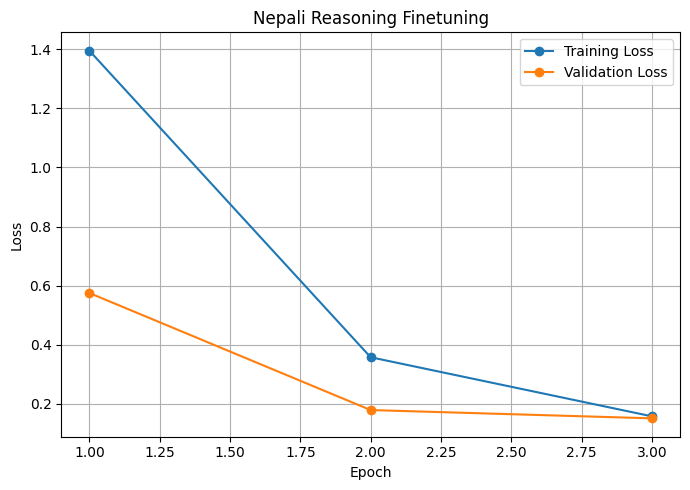

In [48]:
# ============================================================
# CELL 48 — FINETUNING LOSS CURVE
# ============================================================

# Plot train vs. validation loss across epochs and save the figure — the
# standard "did finetuning converge / did it start overfitting" chart.

import matplotlib.pyplot as plt


epochs = [
    x["epoch"]
    for x in training_history
]


train_losses = [
    x["train_loss"]
    for x in training_history
]


validation_losses = [
    x["validation_loss"]
    for x in training_history
]


plt.figure(
    figsize=(7, 5)
)


plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)


plt.plot(
    epochs,
    validation_losses,
    marker="o",
    label="Validation Loss"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Nepali Reasoning Finetuning"
)

plt.legend()

plt.grid()

plt.tight_layout()


plt.savefig(
    PHASE3_DIR
    / "finetuning_loss.png",
    dpi=200
)


plt.show()

In [49]:
# ============================================================
# CELL 49 — LOAD BEST FINETUNED MODEL
# ============================================================

# Load the BEST (lowest validation loss) finetuned checkpoint back into `model`,
# rather than whatever the last epoch happened to leave it at — this is the
# checkpoint used for every finetuned-model evaluation below.

best_checkpoint = torch.load(
    BEST_FT_CHECKPOINT,
    map_location=device,
    weights_only=False
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ],
    strict=True
)


model.eval()


print(
    "Best epoch:",
    best_checkpoint[
        "epoch"
    ] + 1
)


print(
    "Best validation loss:",
    best_checkpoint[
        "val_loss"
    ]
)


print(
    "✓ Best finetuned model loaded."
)

Best epoch: 3
Best validation loss: 0.15115050988892714
✓ Best finetuned model loaded.


In [50]:
# ============================================================
# CELL 50 — FINETUNED QUICK TEST
# ============================================================

# Same qualitative smoke test as the earlier pretrained-only version (CELL 31 /
# index 25), but now using the finetuned model, to eyeball improvement.

for example in test_examples[:10]:

    prediction = generate_reasoning_answer(
        model,
        example["prompt"]
    )


    prediction = normalize_answer(
        prediction
    )


    gold = normalize_answer(
        example["answer"]
    )


    print(
        "\n" + "=" * 70
    )


    print(
        "Template:",
        example["template"]
    )


    print("\nQuestion:")

    print(
        example["prompt"]
    )


    print(
        "\nGold answer:",
        gold
    )


    print(
        "Finetuned answer:",
        prediction
    )


    print(
        "Correct:",
        prediction == gold
    )
    


Template: T5

Question:
तरुण सँग रातो झोला छ.
अनिता लाई आँप मन पर्छ.
लता हरिका भन्दा अग्लो छन्।
हरिका अनिता भन्दा अग्लो छन्।
अनिता तरुण भन्दा अग्लो छन्।
लता, तरुण — यीमध्ये को अग्लो छ?

Gold answer: लता
Finetuned answer: लता
Correct: True

Template: T6

Question:
भरत सँग तुलना गर्दा मेघना ले बढी अंक ल्याए।
मेघना सँग तुलना गर्दा रोहित ले बढी अंक ल्याए।
रोहित ले पवन भन्दा कम अंक ल्याए।
पवन, भरत — यीमध्ये कसले कम अंक ल्याए?

Gold answer: भरत
Finetuned answer: भरत
Correct: True

Template: T3

Question:
वर्षा दीपक भन्दा अग्लो छन्।
दीपक स्वाति भन्दा अग्लो छन्।
वर्षा, स्वाति — यीमध्ये को होचो छ?

Gold answer: स्वाति
Finetuned answer: स्वाति
Correct: True

Template: T3

Question:
सीता ले गोपाल भन्दा बढी अंक ल्याए।
प्रणय सँग तुलना गर्दा गोपाल ले बढी अंक ल्याए।
सीता, प्रणय — यीमध्ये कसले कम अंक ल्याए?

Gold answer: प्रणय
Finetuned answer: प्रणय
Correct: True

Template: T2

Question:
गोपाल ले 48 अंक ल्याए.
महेश ले 88 अंक ल्याए.
गोपाल ले ल्याएको अंक महेश ले ल्याएको भन्दा बढी हो, कम हो, कि बराबर ह

In [51]:
# ============================================================
# CELL 51 — FINETUNED TEST EVALUATION
# ============================================================

# Run the same evaluate_reasoning() harness used for the pretrained baseline, now
# on the finetuned model, over the full TEST split.

finetuned_metrics, finetuned_results = (
    evaluate_reasoning(

        model,

        test_examples,

        description=(
            "Finetuned reasoning evaluation"
        )
    )
)

Finetuned reasoning evaluation:   0%|          | 0/1200 [00:00<?, ?it/s]

In [52]:
# Pretty-print the finetuned results in the same format as the pretrained
# baseline, for a direct side-by-side comparison.

print(
    "\n" + "=" * 60
)

print(
    "FINETUNED REASONING RESULTS"
)

print(
    "=" * 60
)


print(
    "\nTotal test examples:",
    finetuned_metrics[
        "total_examples"
    ]
)


print(
    "Correct:",
    finetuned_metrics[
        "correct_examples"
    ]
)


print(
    "Overall exact-match accuracy:",
    f"{finetuned_metrics['overall_exact_match']:.4f}"
)


print(
    "\nTemplate-wise accuracy:"
)


for template, accuracy in (
    finetuned_metrics[
        "template_accuracy"
    ].items()
):

    print(
        f"{template}: "
        f"{accuracy:.4f}"
    )


FINETUNED REASONING RESULTS

Total test examples: 1200
Correct: 971
Overall exact-match accuracy: 0.8092

Template-wise accuracy:
T1: 0.5400
T2: 0.3150
T3: 1.0000
T4: 1.0000
T5: 1.0000
T6: 1.0000


In [53]:
# ============================================================
# CELL 52 — SAVE FINETUNED RESULTS
# ============================================================

# Persist finetuned metrics + full predictions to disk, mirroring what was saved
# for the pretrained baseline.

with open(
    PHASE3_DIR
    / "finetuned_reasoning_metrics.json",

    "w",

    encoding="utf-8"
) as f:

    json.dump(
        finetuned_metrics,
        f,
        ensure_ascii=False,
        indent=2
    )


with open(
    PHASE3_DIR
    / "finetuned_test_predictions.json",

    "w",

    encoding="utf-8"
) as f:

    json.dump(
        finetuned_results,
        f,
        ensure_ascii=False,
        indent=2
    )


print(
    "✓ Finetuned results saved."
)

✓ Finetuned results saved.


In [54]:
# ============================================================
# CELL 53 — PRETRAINED VS FINETUNED
# ============================================================

# WHAT THIS CELL DOES
# Builds the headline pretrained-vs-finetuned comparison table: overall
# accuracy plus each template's accuracy, with an explicit "Improvement"
# column (finetuned minus pretrained). Saved as CSV for the report.

comparison_rows = []


comparison_rows.append({

    "Template": "Overall",

    "Pretrained":
        pretrained_metrics[
            "overall_exact_match"
        ],

    "Finetuned":
        finetuned_metrics[
            "overall_exact_match"
        ]
})


for template in [
    "T1",
    "T2",
    "T3",
    "T4",
    "T5",
    "T6"
]:

    comparison_rows.append({

        "Template":
            template,

        "Pretrained":
            pretrained_metrics[
                "template_accuracy"
            ][template],

        "Finetuned":
            finetuned_metrics[
                "template_accuracy"
            ][template]
    })


comparison_df = pd.DataFrame(
    comparison_rows
)


comparison_df[
    "Improvement"
] = (
    comparison_df[
        "Finetuned"
    ]
    -
    comparison_df[
        "Pretrained"
    ]
)


print(
    comparison_df.to_string(
        index=False
    )
)


comparison_df.to_csv(
    PHASE3_DIR
    / "pretrained_vs_finetuned.csv",
    index=False
)

Template  Pretrained  Finetuned  Improvement
 Overall         0.0   0.809167     0.809167
      T1         0.0   0.540000     0.540000
      T2         0.0   0.315000     0.315000
      T3         0.0   1.000000     1.000000
      T4         0.0   1.000000     1.000000
      T5         0.0   1.000000     1.000000
      T6         0.0   1.000000     1.000000


In [55]:
# ============================================================
# CHECK T1 VALIDATION PREDICTIONS
# ============================================================

# WHAT THIS CELL DOES
# Manual error-inspection pass restricted to template T1 (using the VALIDATION
# split, not test, so this doesn't touch the held-out test numbers). Prints
# prompt/gold/prediction for the first 20 T1 validation examples to eyeball
# failure patterns that the aggregate accuracy number alone wouldn't show.

t1_val = [
    x for x in val_examples
    if x["template"] == "T1"
]

for example in t1_val[:20]:

    prediction = generate_reasoning_answer(
        model,
        example["prompt"]
    )

    prediction = normalize_answer(
        prediction
    )

    gold = normalize_answer(
        example["answer"]
    )

    print("\n" + "=" * 60)
    print(example["prompt"])

    print("\nGold      :", gold)
    print("Prediction:", prediction)
    print("Correct   :", prediction == gold)


विक्रम को उमेर 68 वर्ष हो.
संदीप को उमेर 35 वर्ष हो.
विक्रम, संदीप — यीमध्ये कसको उमेर बढी छ?

Gold      : विक्रम
Prediction: संदीप
Correct   : False

सुरेश सँग 19 वटा किताब छन्.
हरिका सँग 81 वटा किताब छन्.
सुरेश, हरिका — यीमध्ये कोसँग कम किताब छन्?

Gold      : सुरेश
Prediction: हरिका
Correct   : False

अर्जुन सँग 3970 रुपैयाँ छन्.
सुरेश सँग 1365 रुपैयाँ छन्.
अर्जुन, सुरेश — यीमध्ये कोसँग कम पैसा छ?

Gold      : सुरेश
Prediction: सुरेश
Correct   : True

हरिका सँग 2371 रुपैयाँ छन्.
दीप्ति सँग 1384 रुपैयाँ छन्.
हरिका, दीप्ति — यीमध्ये कोसँग कम पैसा छ?

Gold      : दीप्ति
Prediction: हरिका
Correct   : False

दीपक को उमेर 18 वर्ष हो.
नवीन को उमेर 37 वर्ष हो.
दीपक, नवीन — यीमध्ये कसको उमेर बढी छ?

Gold      : नवीन
Prediction: नवीन
Correct   : True

अनिता सँग 56 वटा किताब छन्.
श्रावणी सँग 47 वटा किताब छन्.
अनिता, श्रावणी — यीमध्ये कोसँग कम किताब छन्?

Gold      : श्रावणी
Prediction: अनिता
Correct   : False

काव्या सँग 4155 रुपैयाँ छन्.
श्रावणी सँग 3983 रुपैयाँ छन्.
काव्या, श्रावणी — यीमध्य

In [56]:
# Re-print the resolved dataset paths — sanity check before the ablation study
# below, to confirm we're still pointed at the same train/val/test files.

print("TRAIN FILE:", TRAIN_FILE)
print("VAL FILE  :", VAL_FILE)
print("TEST FILE :", TEST_FILE)

TRAIN FILE: /kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/train.jsonl
VAL FILE  : /kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/validation.jsonl
TEST FILE : /kaggle/input/datasets/tanoojtadepalli/nepali-phase3-dataset/nepali_reasoning_dataset_shared_names/test.jsonl


In [58]:
# ============================================================
# CELL 54 — LOAD PRETRAINED AND FINETUNED MODELS
# ============================================================

# WHAT THIS CELL DOES
# Start of the attention-analysis section. Loads two separate model instances
# into memory at once — the untouched Phase 2 pretrained checkpoint and the
# best finetuned checkpoint — so their internal attention patterns on the same
# input can be directly compared side by side.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ATTN_DIR = (
    PHASE3_DIR
    / "attention_analysis"
)

ATTN_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# PRETRAINED MODEL
# ------------------------------------------------------------

pretrained_model = Transformer(
    config
).to(device)

pretrained_checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

pretrained_model.load_state_dict(
    pretrained_checkpoint[
        "model_state_dict"
    ],
    strict=True
)

pretrained_model.eval()


# ------------------------------------------------------------
# FINETUNED MODEL
# ------------------------------------------------------------

finetuned_model = Transformer(
    config
).to(device)

finetuned_checkpoint = torch.load(
    BEST_FT_CHECKPOINT,
    map_location=device,
    weights_only=False
)

finetuned_model.load_state_dict(
    finetuned_checkpoint[
        "model_state_dict"
    ],
    strict=True
)

finetuned_model.eval()


print("✓ Pretrained model loaded")
print("✓ Finetuned model loaded")

print(
    "Best finetuned epoch:",
    finetuned_checkpoint["epoch"] + 1
)

✓ Pretrained model loaded
✓ Finetuned model loaded
Best finetuned epoch: 3


In [59]:
# ============================================================
# CELL 55 — SELECT REASONING PROMPT
# ============================================================

# Pick one concrete example to run the attention analysis on: scan template T6
# test examples for the first one the FINETUNED model gets exactly right, so
# the attention visualizations below are illustrating a genuine success case
# rather than a failure.

attention_example = None


for example in test_examples:

    if example["template"] != "T6":
        continue

    prediction = generate_reasoning_answer(
        finetuned_model,
        example["prompt"]
    )

    prediction = normalize_answer(
        prediction
    )

    gold = normalize_answer(
        example["answer"]
    )

    if prediction == gold:

        attention_example = example
        break


assert attention_example is not None


print("=" * 70)
print("ATTENTION ANALYSIS EXAMPLE")
print("=" * 70)

print(
    "\nTemplate:",
    attention_example["template"]
)

print("\nQuestion:")
print(
    attention_example["prompt"]
)

print(
    "\nGold answer:",
    attention_example["answer"]
)

ATTENTION ANALYSIS EXAMPLE

Template: T6

Question:
भरत सँग तुलना गर्दा मेघना ले बढी अंक ल्याए।
मेघना सँग तुलना गर्दा रोहित ले बढी अंक ल्याए।
रोहित ले पवन भन्दा कम अंक ल्याए।
पवन, भरत — यीमध्ये कसले कम अंक ल्याए?

Gold answer: भरत


In [60]:
# ============================================================
# CELL 56 — PREDICTIONS ON SAME PROMPT
# ============================================================

# Generate predictions from both models on that same chosen example, purely to
# display alongside the attention heatmaps for context.

pretrained_prediction = (
    generate_reasoning_answer(
        pretrained_model,
        attention_example["prompt"]
    )
)


finetuned_prediction = (
    generate_reasoning_answer(
        finetuned_model,
        attention_example["prompt"]
    )
)


print(
    "Gold       :",
    attention_example["answer"]
)

print(
    "Pretrained :",
    pretrained_prediction
)

print(
    "Finetuned  :",
    finetuned_prediction
)

Gold       : भरत
Pretrained : को कुरा हो , उनले भने , हामीले पनि यो
Finetuned  : भरत


In [61]:
# ============================================================
# CELL 57 — BUILD ATTENTION INPUT
# ============================================================

# Tokenize the chosen example's prompt (question + prefixes, no answer) into the
# exact input the attention matrices below correspond to, and also convert IDs
# to human-readable SentencePiece pieces for axis labels on the heatmaps.

attention_text = (
    QUESTION_PREFIX
    + attention_example["prompt"]
    + ANSWER_PREFIX
)


attention_ids = sp.encode(
    attention_text,
    out_type=int
)


attention_tensor = torch.tensor(
    attention_ids,
    dtype=torch.long,
    device=device
).unsqueeze(0)


pieces = [
    sp.id_to_piece(token_id)
    for token_id in attention_ids
]


print(
    "Number of tokens:",
    len(attention_ids)
)

print(
    "\nInput text:"
)

print(attention_text)

Number of tokens: 61

Input text:
प्रश्न:
भरत सँग तुलना गर्दा मेघना ले बढी अंक ल्याए।
मेघना सँग तुलना गर्दा रोहित ले बढी अंक ल्याए।
रोहित ले पवन भन्दा कम अंक ल्याए।
पवन, भरत — यीमध्ये कसले कम अंक ल्याए?
जवाफ:



In [62]:
# ============================================================
# CELL 58 — EXTRACT ATTENTION MATRICES
# ============================================================

# WHAT THIS CELL DOES
# extract_attentions(): runs a forward pass with return_attentions=True to get
# per-layer attention weight tensors, then drops the batch dimension (batch
# size is always 1 here) and detaches/moves them to CPU for plotting/analysis.
# Called once for each of the pretrained and finetuned models on the identical
# input, so the resulting matrices are directly comparable.

@torch.inference_mode()
def extract_attentions(
    model,
    input_tensor
):

    model.eval()

    output = model(
        input_tensor,
        return_attentions=True
    )


    # Expected:
    #
    # logits, attentions
    #
    logits, attentions = output


    # Convert:
    #
    # [batch, heads, seq, seq]
    #
    # to:
    #
    # [heads, seq, seq]
    #

    attentions = [

        layer_attention[0]
        .detach()
        .cpu()

        for layer_attention
        in attentions
    ]


    return (
        logits,
        attentions
    )


_, pretrained_attentions = (
    extract_attentions(
        pretrained_model,
        attention_tensor
    )
)


_, finetuned_attentions = (
    extract_attentions(
        finetuned_model,
        attention_tensor
    )
)


print(
    "Number of layers:",
    len(pretrained_attentions)
)

print(
    "Attention shape:",
    pretrained_attentions[0].shape
)

Number of layers: 12
Attention shape: torch.Size([8, 61, 61])


In [63]:
# ============================================================
# CELL 59 — ATTENTION SANITY CHECK
# ============================================================

# Confirm both models produced one attention tensor per layer, and that
# pretrained vs. finetuned attention shapes match exactly (same seq length,
# same head count) — a prerequisite for the side-by-side comparisons below.

assert (
    len(pretrained_attentions)
    == config["n_layers"]
)

assert (
    len(finetuned_attentions)
    == config["n_layers"]
)


for layer in range(
    config["n_layers"]
):

    assert (
        pretrained_attentions[layer].shape
        ==
        finetuned_attentions[layer].shape
    )


print(
    "✓ Attention tensors verified."
)

✓ Attention tensors verified.


In [64]:
# ============================================================
# CELL 60 — TOKEN LABELS
# ============================================================

# Build short, display-friendly labels for each token (truncate long pieces so
# heatmap tick labels stay readable) and print them with their index for
# reference when reading the heatmaps below.

def clean_piece(piece):

    piece = piece.replace(
        "▁",
        "▁"
    )

    if len(piece) > 12:
        piece = piece[:12] + "…"

    return piece


token_labels = [
    clean_piece(x)
    for x in pieces
]


for i, token in enumerate(
    token_labels
):

    print(
        i,
        token
    )

0 ▁प्रश्न
1 <0x3A>
2 <0x0A>
3 भर
4 त
5 ▁सँग
6 ▁तुलना
7 ▁गर्दा
8 ▁मेघ
9 ना
10 ▁ले
11 ▁बढी
12 ▁अंक
13 ▁ल्याए
14 ।
15 <0x0A>
16 मे
17 घ
18 ना
19 ▁सँग
20 ▁तुलना
21 ▁गर्दा
22 ▁रोहित
23 ▁ले
24 ▁बढी
25 ▁अंक
26 ▁ल्याए
27 ।
28 <0x0A>
29 रो
30 हित
31 ▁ले
32 ▁पवन
33 ▁भन्दा
34 ▁कम
35 ▁अंक
36 ▁ल्याए
37 ।
38 <0x0A>
39 प
40 वन
41 ,
42 ▁भरत
43 ▁
44 <0xE2>
45 <0x80>
46 <0x94>
47 ▁यी
48 मध्ये
49 ▁कस
50 ले
51 ▁कम
52 ▁अंक
53 ▁ल्याए
54 ?
55 <0x0A>
56 ज
57 वा
58 फ
59 <0x3A>
60 <0x0A>


In [65]:
# ============================================================
# CELL 61 — ATTENTION HEATMAP FUNCTION
# ============================================================

# WHAT THIS CELL DOES
# Renders one attention matrix as a heatmap: either a single head, or (when
# head=None) the average across all heads in that layer. Query tokens on the
# y-axis, key tokens on the x-axis — cell (i, j) is how much query position i
# attends to key position j. Figure size scales with sequence length so long
# sequences don't produce illegibly tiny cells. Tick labels are subsampled
# (`step`) for the same reason. Saves to disk in addition to displaying inline.

def plot_attention_heatmap(
    attention,
    labels,
    title,
    save_path,
    head=None
):

    # attention:
    # [heads, seq, seq]


    if head is None:

        matrix = (
            attention
            .mean(dim=0)
            .numpy()
        )

        head_label = (
            "Average of all heads"
        )

    else:

        matrix = (
            attention[head]
            .numpy()
        )

        head_label = (
            f"Head {head + 1}"
        )


    seq_len = len(labels)


    figure_size = max(
        9,
        min(
            18,
            seq_len * 0.25
        )
    )


    plt.figure(
        figsize=(
            figure_size,
            figure_size
        )
    )


    plt.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest"
    )


    plt.colorbar(
        label="Attention Weight"
    )


    # Reduce label density for long sequences
    step = max(
        1,
        seq_len // 35
    )


    ticks = list(
        range(
            0,
            seq_len,
            step
        )
    )


    plt.xticks(
        ticks,
        [
            labels[i]
            for i in ticks
        ],
        rotation=90,
        fontsize=7
    )


    plt.yticks(
        ticks,
        [
            labels[i]
            for i in ticks
        ],
        fontsize=7
    )


    plt.xlabel(
        "Key Tokens"
    )

    plt.ylabel(
        "Query Tokens"
    )


    plt.title(
        title
        + "\n"
        + head_label
    )


    plt.tight_layout()


    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )


    plt.show()
    

/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2349 (\N{DEVANAGARI LETTER BHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

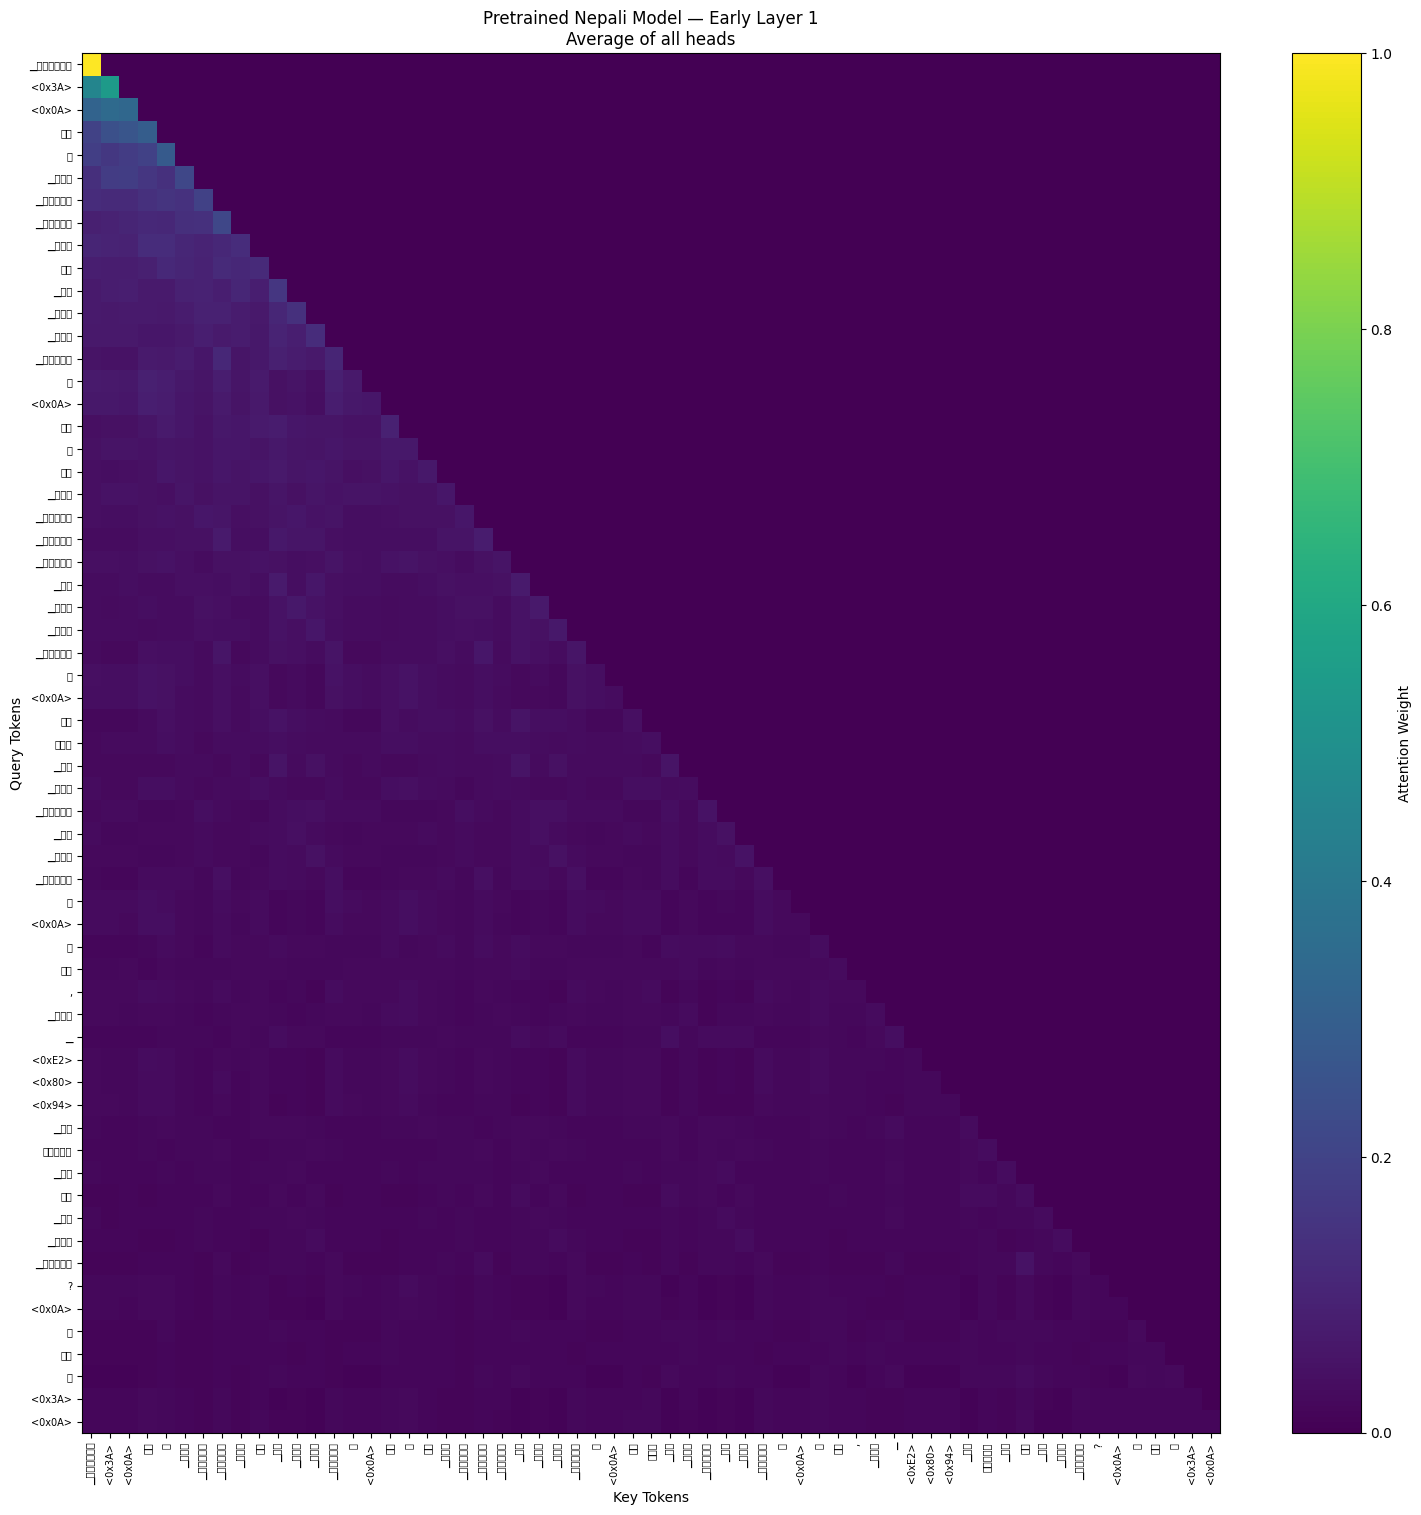

/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2349 (\N{DEVANAGARI LETTER BHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

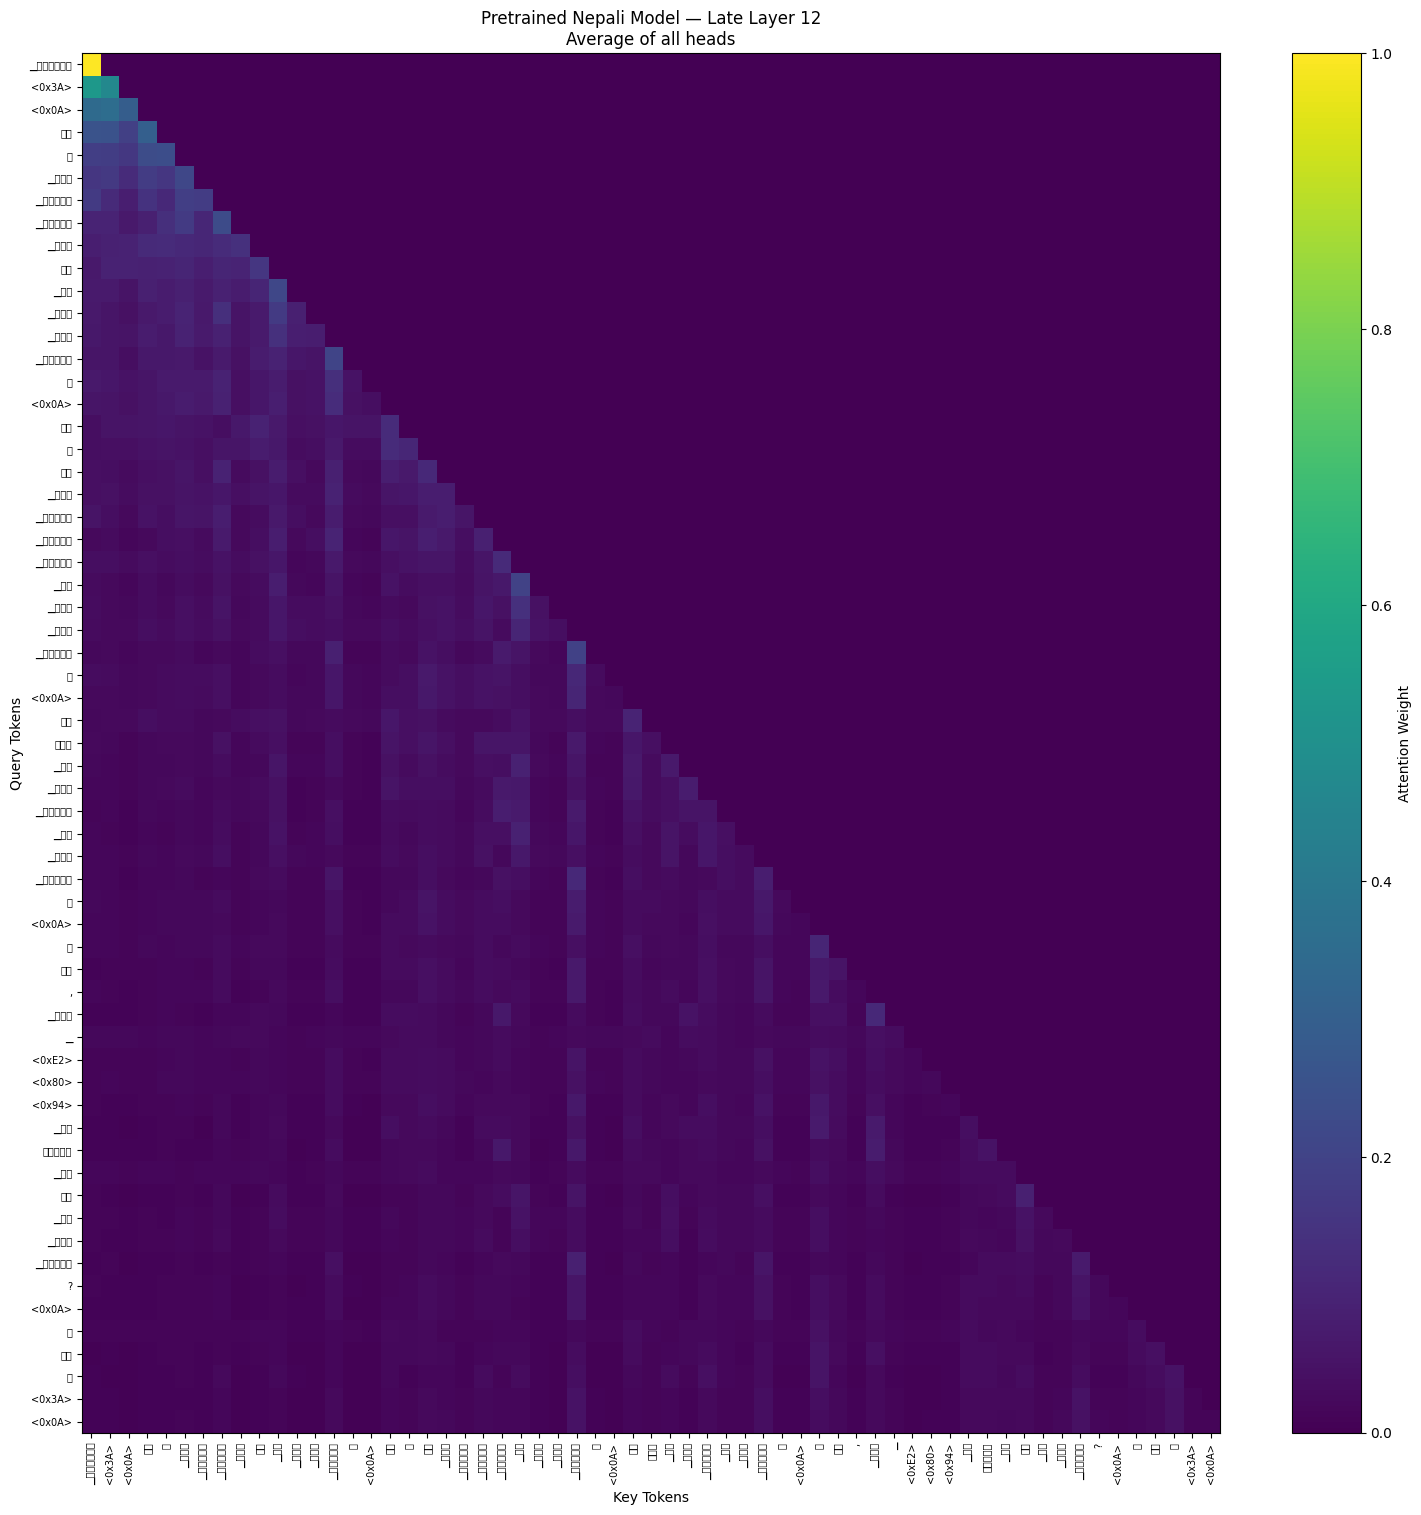

/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2349 (\N{DEVANAGARI LETTER BHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

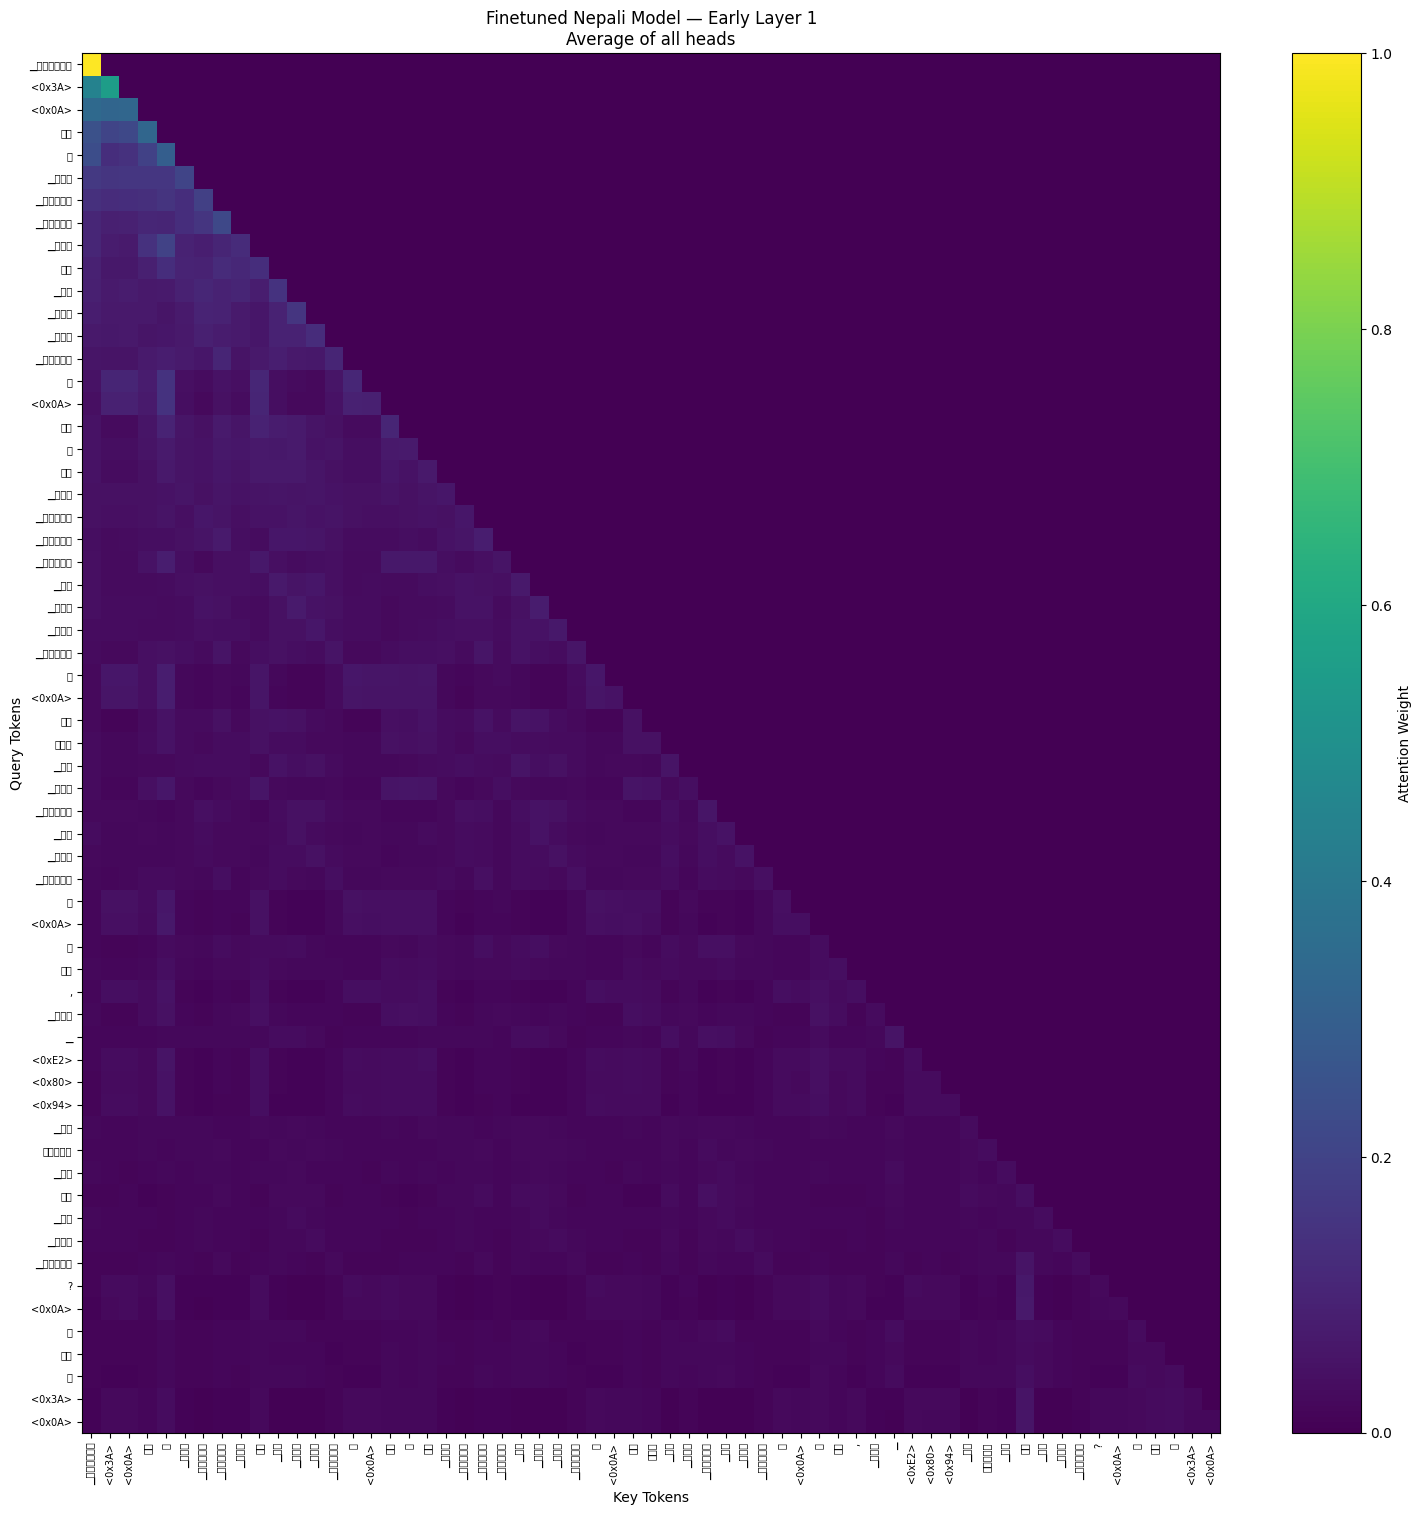

/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3746280650.py:126: UserWarning: Glyph 2349 (\N{DEVANAGARI LETTER BHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

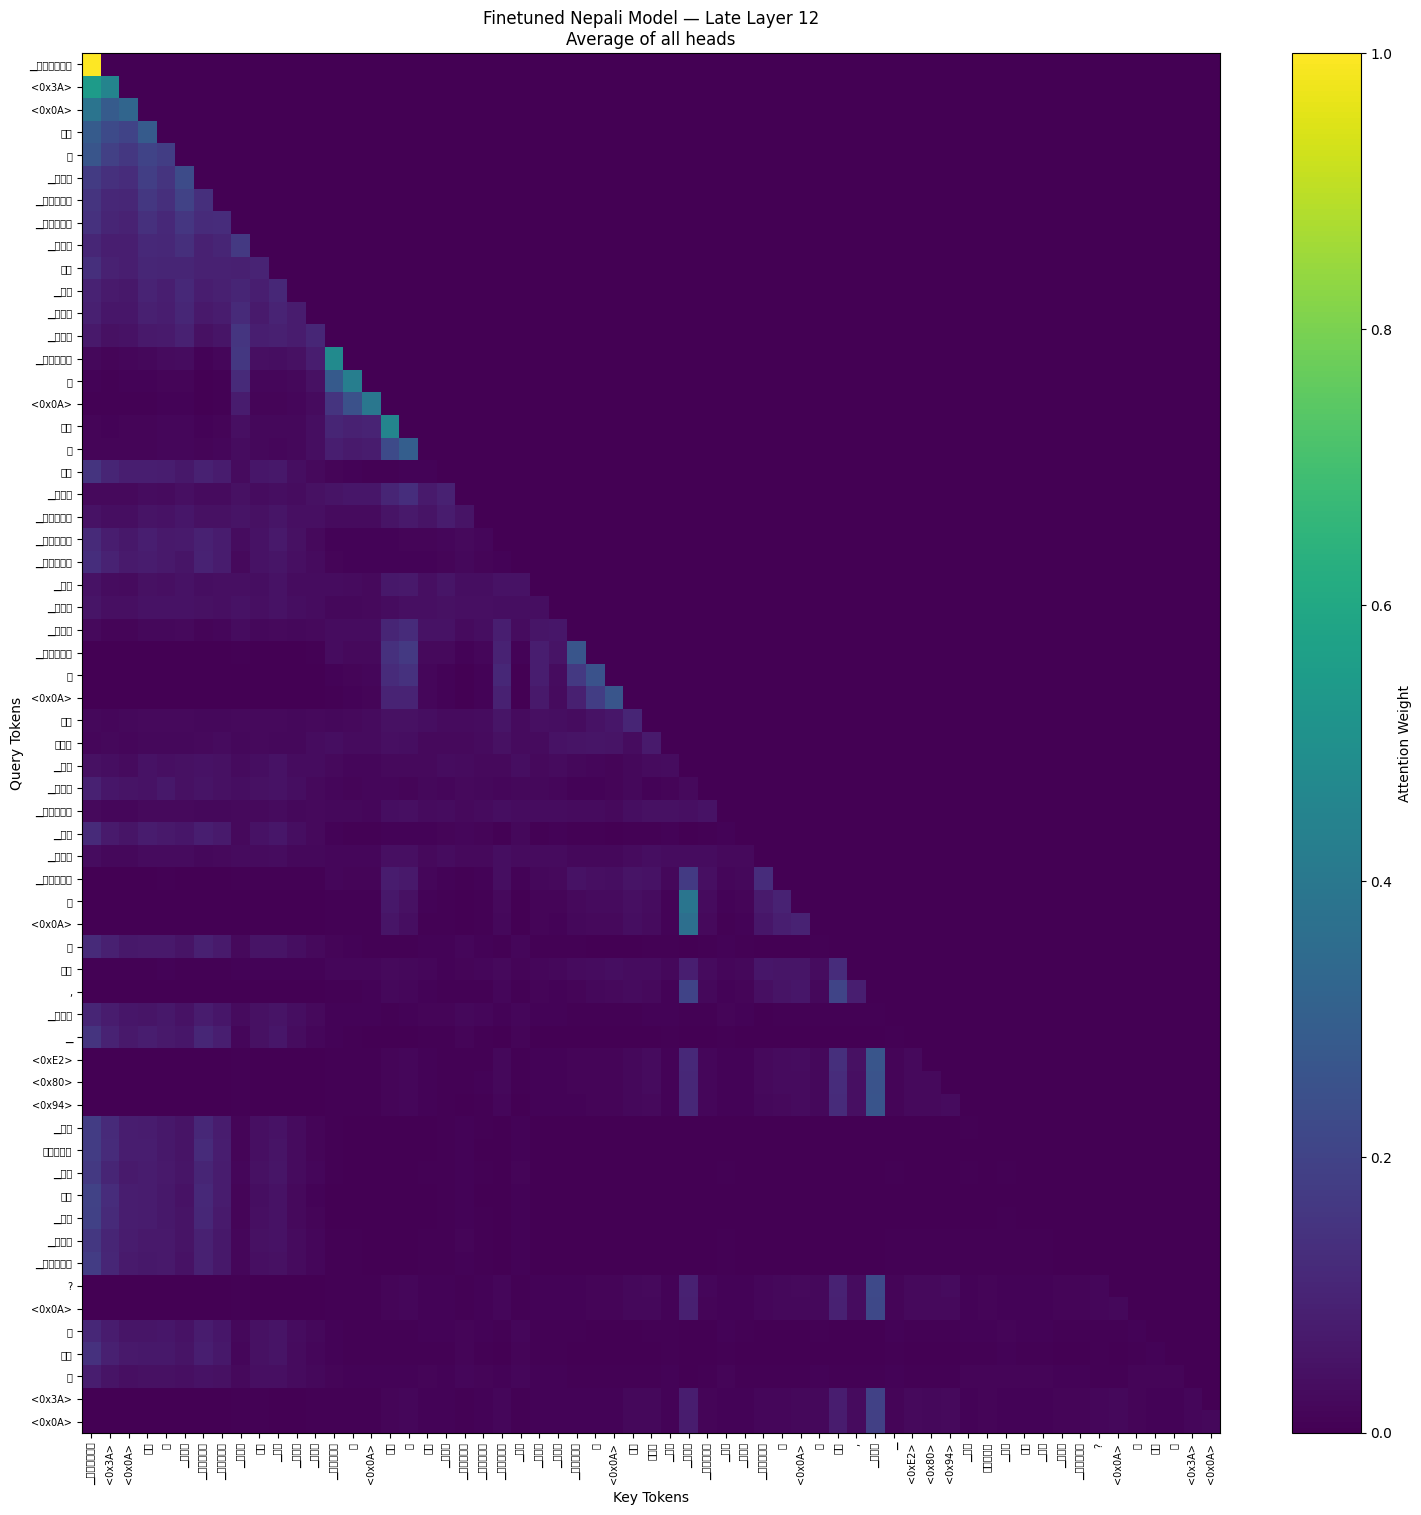

In [66]:
# ============================================================
# CELL 62 — PRETRAINED VS FINETUNED HEATMAPS
# ============================================================

# Generate the four core comparison heatmaps: pretrained vs. finetuned, each at
# an early layer and a late layer (averaged across heads). The usual pattern to
# look for is early layers attending mostly locally/uniformly and late layers
# developing more specialized, longer-range patterns — and for finetuning to
# sharpen that further if it's teaching the model to use reasoning context.

EARLY_LAYER = 0

LATE_LAYER = (
    config["n_layers"] - 1
)


# ------------------------------------------------------------
# PRETRAINED — EARLY
# ------------------------------------------------------------

plot_attention_heatmap(

    pretrained_attentions[
        EARLY_LAYER
    ],

    token_labels,

    title=(
        "Pretrained Nepali Model"
        " — Early Layer"
        f" {EARLY_LAYER + 1}"
    ),

    save_path=(
        ATTN_DIR
        / "pretrained_early_layer.png"
    )
)


# ------------------------------------------------------------
# PRETRAINED — LATE
# ------------------------------------------------------------

plot_attention_heatmap(

    pretrained_attentions[
        LATE_LAYER
    ],

    token_labels,

    title=(
        "Pretrained Nepali Model"
        " — Late Layer"
        f" {LATE_LAYER + 1}"
    ),

    save_path=(
        ATTN_DIR
        / "pretrained_late_layer.png"
    )
)


# ------------------------------------------------------------
# FINETUNED — EARLY
# ------------------------------------------------------------

plot_attention_heatmap(

    finetuned_attentions[
        EARLY_LAYER
    ],

    token_labels,

    title=(
        "Finetuned Nepali Model"
        " — Early Layer"
        f" {EARLY_LAYER + 1}"
    ),

    save_path=(
        ATTN_DIR
        / "finetuned_early_layer.png"
    )
)


# ------------------------------------------------------------
# FINETUNED — LATE
# ------------------------------------------------------------

plot_attention_heatmap(

    finetuned_attentions[
        LATE_LAYER
    ],

    token_labels,

    title=(
        "Finetuned Nepali Model"
        " — Late Layer"
        f" {LATE_LAYER + 1}"
    ),

    save_path=(
        ATTN_DIR
        / "finetuned_late_layer.png"
    )
)

In [67]:
# ============================================================
# CELL 63 — ATTENTION METRICS
# ============================================================

# WHAT THIS CELL DOES
# compute_attention_metrics(): for every (layer, head), computes two per-head
# summary statistics averaged over query positions:
#   - Normalized entropy of the attention distribution at each query position
#     (entropy / log(num_valid_keys), so it's on a 0-1 scale regardless of
#     sequence length) — low = attention concentrated on a few tokens ,
#     high = spread out roughly uniformly.
#   - Mean attention distance: the attention-weighted average of
#     (query_position - key_position), i.e. how far back (in tokens) that head
#     tends to look on average.
# Only keys at positions <= the query position are included, matching the
# model's causal masking (a query genuinely cannot attend beyond itself).
# Returns one row per (layer, head) as a tidy DataFrame for further analysis.

def compute_attention_metrics(
    attention_layers,
    model_name
):

    rows = []


    for layer_index, attention in enumerate(
        attention_layers
    ):

        # attention:
        # [heads, seq, seq]

        num_heads = attention.shape[0]
        seq_len = attention.shape[1]


        for head_index in range(
            num_heads
        ):

            head_attention = (
                attention[
                    head_index
                ]
                .numpy()
            )


            entropy_values = []
            distance_values = []


            for query_position in range(
                seq_len
            ):

                # Causal model:
                # Only positions <= query_position
                # are allowed.

                probs = (
                    head_attention[
                        query_position,
                        :query_position + 1
                    ]
                )


                total = probs.sum()


                if total <= 0:
                    continue


                probs = (
                    probs / total
                )


                # --------------------------------------------
                # NORMALIZED ENTROPY
                # --------------------------------------------

                if query_position > 0:

                    entropy = -np.sum(

                        probs
                        * np.log(
                            probs + 1e-12
                        )
                    )


                    max_entropy = (
                        np.log(
                            query_position + 1
                        )
                    )


                    normalized_entropy = (
                        entropy
                        / max_entropy
                    )


                    entropy_values.append(
                        normalized_entropy
                    )


                # --------------------------------------------
                # MEAN ATTENTION DISTANCE
                # --------------------------------------------

                key_positions = np.arange(
                    query_position + 1
                )


                distances = (
                    query_position
                    - key_positions
                )


                mean_distance = np.sum(
                    probs * distances
                )


                distance_values.append(
                    mean_distance
                )


            rows.append({

                "Model":
                    model_name,

                "Layer":
                    layer_index + 1,

                "Head":
                    head_index + 1,

                "Normalized_Entropy":
                    float(
                        np.mean(
                            entropy_values
                        )
                    ),

                "Mean_Attention_Distance":
                    float(
                        np.mean(
                            distance_values
                        )
                    ),
            })


    return pd.DataFrame(
        rows
    )

In [68]:
# ============================================================
# CELL 64 — PRETRAINED VS FINETUNED METRICS
# ============================================================

# Compute these per-head metrics for both models and concatenate into one
# DataFrame (with a "Model" column) for easy side-by-side filtering/plotting,
# then save the full per-head table to disk.

pretrained_attention_metrics = (
    compute_attention_metrics(
        pretrained_attentions,
        "Pretrained"
    )
)


finetuned_attention_metrics = (
    compute_attention_metrics(
        finetuned_attentions,
        "Finetuned"
    )
)


attention_metrics_df = pd.concat(

    [
        pretrained_attention_metrics,
        finetuned_attention_metrics
    ],

    ignore_index=True
)


attention_metrics_df.to_csv(

    ATTN_DIR
    / "attention_metrics_all_heads.csv",

    index=False
)


print(
    attention_metrics_df.head()
)

        Model  Layer  Head  Normalized_Entropy  Mean_Attention_Distance
0  Pretrained      1     1            0.980375                14.459472
1  Pretrained      1     2            0.982079                14.869297
2  Pretrained      1     3            0.968335                14.658925
3  Pretrained      1     4            0.966457                14.480516
4  Pretrained      1     5            0.974735                15.033368


In [69]:
# ============================================================
# CELL 65 — EARLY VS LATE SUMMARY
# ============================================================

# Collapse the per-head metrics down to one row per (model, early/late layer),
# averaging across heads — a compact top-line summary of "did attention get
# more focused / longer-range after finetuning", saved to CSV.

summary_rows = []


for model_name in [
    "Pretrained",
    "Finetuned"
]:

    model_df = (
        attention_metrics_df[
            attention_metrics_df[
                "Model"
            ]
            == model_name
        ]
    )


    for label, layer_number in [

        (
            "Early",
            EARLY_LAYER + 1
        ),

        (
            "Late",
            LATE_LAYER + 1
        )
    ]:

        layer_df = (
            model_df[
                model_df[
                    "Layer"
                ]
                == layer_number
            ]
        )


        summary_rows.append({

            "Model":
                model_name,

            "Layer_Type":
                label,

            "Layer":
                layer_number,

            "Mean_Normalized_Entropy":
                layer_df[
                    "Normalized_Entropy"
                ].mean(),

            "Mean_Attention_Distance":
                layer_df[
                    "Mean_Attention_Distance"
                ].mean()
        })


attention_summary = pd.DataFrame(
    summary_rows
)


print(
    attention_summary.to_string(
        index=False
    )
)


attention_summary.to_csv(

    ATTN_DIR
    / "early_late_attention_summary.csv",

    index=False
)

     Model Layer_Type  Layer  Mean_Normalized_Entropy  Mean_Attention_Distance
Pretrained      Early      1                 0.975095                14.778005
Pretrained       Late     12                 0.904567                13.120399
 Finetuned      Early      1                 0.941874                14.583438
 Finetuned       Late     12                 0.812561                15.829982


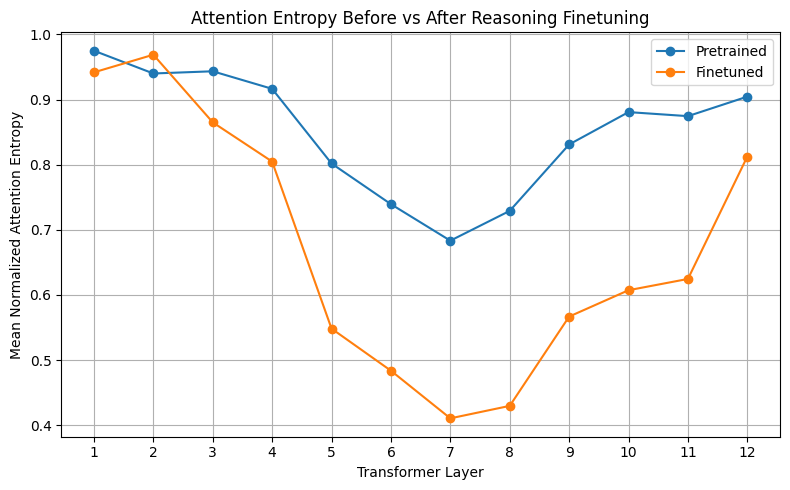

In [70]:
# ============================================================
# CELL 66 — ENTROPY ACROSS LAYERS
# ============================================================

# Line plot: mean normalized attention entropy per layer, one line per model.
# Shows whether finetuning shifted how concentrated vs. diffuse attention is at
# each depth of the network.

layer_summary = (

    attention_metrics_df

    .groupby(
        [
            "Model",
            "Layer"
        ]
    )

    .agg(

        Mean_Entropy=(
            "Normalized_Entropy",
            "mean"
        ),

        Mean_Distance=(
            "Mean_Attention_Distance",
            "mean"
        )

    )

    .reset_index()
)


plt.figure(
    figsize=(8, 5)
)


for model_name in [
    "Pretrained",
    "Finetuned"
]:

    subset = (
        layer_summary[
            layer_summary[
                "Model"
            ]
            == model_name
        ]
    )


    plt.plot(
        subset["Layer"],
        subset["Mean_Entropy"],
        marker="o",
        label=model_name
    )


plt.xlabel("Transformer Layer")

plt.ylabel(
    "Mean Normalized Attention Entropy"
)

plt.title(
    "Attention Entropy Before vs After Reasoning Finetuning"
)

plt.xticks(
    range(
        1,
        config["n_layers"] + 1
    )
)

plt.legend()

plt.grid()

plt.tight_layout()


plt.savefig(
    ATTN_DIR
    / "attention_entropy_by_layer.png",
    dpi=200
)

plt.show()

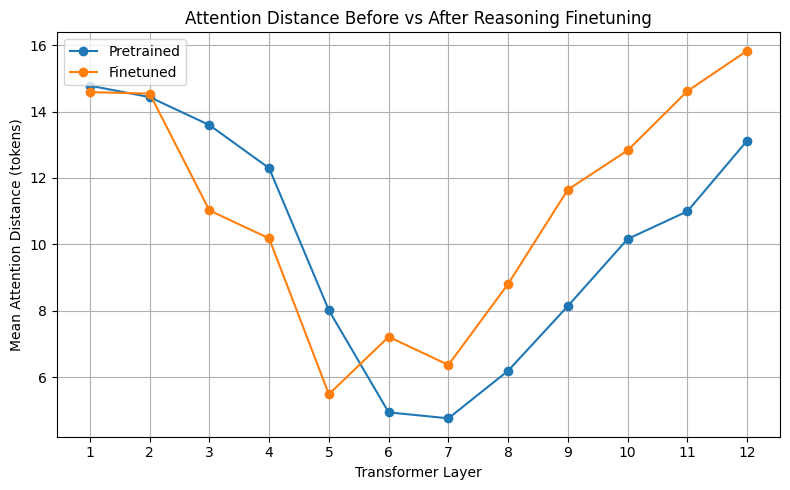

In [71]:
# ============================================================
# CELL 67 — ATTENTION DISTANCE ACROSS LAYERS
# ============================================================

# Same idea as the entropy plot above, but for mean attention distance per
# layer — shows whether finetuning changed how far back (in tokens) each layer
# tends to look.

plt.figure(
    figsize=(8, 5)
)


for model_name in [
    "Pretrained",
    "Finetuned"
]:

    subset = (
        layer_summary[
            layer_summary[
                "Model"
            ]
            == model_name
        ]
    )


    plt.plot(
        subset["Layer"],
        subset["Mean_Distance"],
        marker="o",
        label=model_name
    )


plt.xlabel(
    "Transformer Layer"
)

plt.ylabel(
    "Mean Attention Distance (tokens)"
)

plt.title(
    "Attention Distance Before vs After Reasoning Finetuning"
)

plt.xticks(
    range(
        1,
        config["n_layers"] + 1
    )
)

plt.legend()

plt.grid()

plt.tight_layout()


plt.savefig(
    ATTN_DIR
    / "attention_distance_by_layer.png",
    dpi=200
)

plt.show()

In [75]:
# ============================================================
# CELL 71 — SAVE ATTENTION EXAMPLE
# ============================================================

# WHAT THIS CELL DOES
# Bundles the chosen attention-analysis example, both models' predictions, and
# the key layer/head indices used above into one JSON record for the report.
#
# FIX: removed a stray "ss" token that was sitting on its own line inside the
# dict literal below (between the "template" and "prompt" entries). That is
# invalid Python — a dict entry must be `key: value`, not a bare name — and
# would raise `SyntaxError: ':' expected after dictionary key` the next time
# this cell is run, even though the notebook's saved output shows a successful
# run from before that line was introduced.

attention_example_record = {

    "template":
        attention_example["template"],
    "prompt":
        attention_example["prompt"],

    "gold_answer":
        attention_example["answer"],

    "pretrained_prediction":
        pretrained_prediction,

    "finetuned_prediction":
        finetuned_prediction,

    "num_tokens":
        len(attention_ids),

    "early_layer":
        EARLY_LAYER + 1,

    "late_layer":
        LATE_LAYER + 1,

    "long_range_finetuned_head":
        long_range_head + 1
}


with open(
    ATTN_DIR
    / "attention_example.json",

    "w",

    encoding="utf-8"
) as f:

    json.dump(
        attention_example_record,
        f,
        ensure_ascii=False,
        indent=2
    )


print(
    "✓ Attention analysis saved to:"
)

print(
    ATTN_DIR
)

✓ Attention analysis saved to:
/kaggle/working/nepali_phase3/attention_analysis
